# Table of contents

* **Introduction**
* **Objectives**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Visualization (EDA)**
* **Features Engineering**
    * Text Cleaning
    * Lemmatization
    * POS Tagging
    * Text Representation (Vectorization)
    * Tokenization
* **Model Training**
    * **Non-Negative Matrix Factorization Model (NMF)**
        * Prediction Results (NMF)
        * Topics Cluster Visualization (NMF)
        * **Hyperparameter Tuning (NMF)**
            * Topics Cluster Visualization (NMF with Best Hyperparameters)
        * Model Validation (NMF)
    * **Latent Semantic Indexing Model (LSI) - Scikit-Learn**
        * Prediction Results (LSI - Scikit-Learn)
        * Topics Cluster Visualization (LSI)
        * **Hyperparameter Tuning (LSI)**
            * Topics Cluster Visualization (LSI with Best Hyperparameters)
        * Model Validation LSI
* **Model Evaluation**
    * **Model Evaluation (NMF)**
        * Topics Coherence Score Evaluation (NMF)
        * Topics Cluster Visualization (NMF)
    * **Model Evaluation (LSI)**
        * Topics Coherence Score Evaluation (LSI)
        * Topics Cluster Visualization (LSI)
    * Model Evaluation Interpretation and Comparison
* **Conclusion**
* **References**

# Introduction

Topic modeling, an unsupervised machine learning technique, is employed here to discover hidden semantic structures within a large collection of scientific paper summaries from the arXiv dataset. This project focuses on the comparative application of two classical algorithms: Non-Negative Matrix Factorization (NMF) and Latent Semantic Indexing (LSI), specifically implemented using Truncated SVD.

# Objectives

The primary objectives of this project are:

- Execute a multi-stage preprocessing pipeline, including cleaning, lemmatization, and advanced Part-of-Speech (POS) filtering.
- Implement and train the NMF and LSI (via Truncated SVD) models using scikit-learn.
- Determine the optimal number of topics ($K$) for both models using a data-driven approach based on Topic Coherence ($C_v$).
- Assess model robustness by evaluating generalization on an unseen test dataset.
- Visualize the learned topics and document clusters using dimensionality reduction techniques like t-SNE and UMAP.
- Compare NMF and LSI in terms of their inherent interpretability, performance, and ability to separate themes.

# Pipeline Overview

The project follows a sequential, end-to-end machine learning pipeline, designed for robust model development and evaluation:

- Data Ingestion: Load the raw dataset into the environment.
- Data Partition: Execute a Train/Test Split to create a hold-out test set for unbiased final evaluation.
- Text Preprocessing: Clean and normalize the text (details below).
- Vectorization: Transform the cleaned text into numerical features using CountVectorizer followed by a TF-IDF Transformer.
- Model Training: Train the NMF Model and the LSI Model (TruncatedSVD) on the feature matrix.
- Hyperparameter Tuning: Systematically search for the optimal number of topics ($k$) using the training set.
- Evaluation & Extraction: Extract the final topics and evaluate them using the Topic Coherence metric.
- Model Evaluation on Test Set: Validate the generalization performance of the tuned models on the unseen test data.
- Visualization: Project document-topic distributions into 2D space using t-SNE and UMAP for qualitative assessment of clustering quality.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Data Type</th>
    <th class="tg-7zrl">Description</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">id</td>
    <td class="tg-7zrl">string / unique identifier</td>
    <td class="tg-0lax">A unique identifier for each research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">title</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The title of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">category</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The arXiv category to which the paper is classified, such as 'Machine Learning' or 'Artificial Intelligence'.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">category_code</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The coded representation for the category of the paper, e.g., 'cs.LG' for Machine Learning and 'cs.AI' for Artificial Intelligence.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">published_date</td>
    <td class="tg-7zrl">date / string</td>
    <td class="tg-0lax">The publication date of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">updated_date</td>
    <td class="tg-7zrl">date / string</td>
    <td class="tg-0lax">The last updated date for the paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">authors</td>
    <td class="tg-7zrl">string (list)</td>
    <td class="tg-0lax">A list of all authors who contributed to the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">first_author</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The first author mentioned in the paper's author list.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">summary</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">A summary or abstract of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">summary_word_count</td>
    <td class="tg-7zrl">integer</td>
    <td class="tg-0lax">The word count of the paper's summary.</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/sumitm004/arxiv-scientific-research-papers-dataset)**

# Approach

**Preprocessing Pipeline Approach**

The preprocessing pipeline is designed to transform raw summaries into clean, meaningful token sequences suitable for accurate topic modeling, thereby maximizing the signal-to-noise ratio. The pipeline proceeds through six main operations:

- Normalization: Expand contractions (e.g., "don't" to "do not") and convert all text to lowercase.
- Cleaning: Remove punctuation and numerical digits.
- Filtering: Eliminate common stop-words and tokens shorter than two characters.
- Canonicalization: Apply lemmatization (using spaCy) to reduce inflected forms of words to a common base (e.g., "estimating" to "estimate").
- Semantic Filtering: Retain only tokens identified as NOUN, PROPN, ADJ, or VERB. This critical step ensures the model focuses solely on content-bearing tokens that define the abstract's subject matter.

**Vectorization**

The cleaned, tokenized text is converted into a numerical format using two sequential steps:

- CountVectorizer: Creates the initial Document-Term Matrix (DTM) based on word counts.
- TfidfTransformer: Converts the raw counts into TF-IDF (Term Frequency-Inverse Document Frequency) weights, giving more prominence to words that are rare but specific to certain documents.

**Model Training Approach**

**1. NMF (Non-Negative Matrix Factorization)**

NMF is a part-based representation learning algorithm. It factors the TF-IDF matrix ($X$) into two matrices: the Document-Topic matrix ($W$) and the Topic-Term matrix ($H$), such that $X \approx \mathbf{W} \cdot \mathbf{H}$.

**Non-Negativity Constraint**

NMF enforces that all elements in $\mathbf{W}$ and $\mathbf{H}$ must be non-negative. This key constraint ensures that the derived topics and their associated term weights are purely additive, making the resulting topics highly interpretable by humans.

**2. LSI (Latent Semantic Indexing via Truncated SVD)**

LSI uses Truncated Singular Value Decomposition (SVD) on the TF-IDF matrix.

- Latent Relationships: LSI captures latent semantic relationships between terms by finding an orthogonal basis for the term space.
- Sign Constraint: Unlike NMF, LSI allows both positive and negative values in its factor matrices. While mathematically powerful, this can make the resulting topics less intuitive to interpret, as a word might contribute positively to one topic and negatively to another.

Both NMF and LSI are trained exclusively on the training set and then tested on the hold-out test set to evaluate generalization.

**3. Hyperparameter Tuning**

A systematic grid search is performed over the number of topics ($K$, where $K \in \{2, \dots, 9\}$) for both NMF and LSI. The $K$ value that yields the highest $C_v$ score is selected as the optimal model complexity, thus ensuring a data-driven tuning process.

**Model Evaluation Approach**

**Topic Coherence ($C_v$)**

The quality of the discovered topics is assessed using Topic Coherence ($C_v$).

- $C_v$ measures the degree of semantic similarity between the top words in a topic. It calculates the co-occurrence of these words in a sliding window across the corpus.
- A higher $C_v$ score indicates a better, more semantically consistent topic that is easily understandable to a human.

**Generalization Assessment**

To ensure the models are robust, their $C_v$ coherence scores are calculated on the previously unseen hold-out test set. A minimal drop in coherence from the training score to the test score confirms that the model is generalizing well and is not overfit to the training data.

**Visualization Insights**

Dimensionality Reduction techniques, specifically t-SNE and UMAP, are applied to the high-dimensional document-topic distributions. The resulting 2D projections allow for the visual inspection of document clusters, helping to confirm whether documents assigned to the same dominant topic form distinct, separable groups.

# Setup Environments

In [ ]:
%%capture
! pip install contractions

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import contractions
from nltk.corpus import stopwords
import string
import spacy
from tqdm import tqdm
import warnings
import nltk
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import umap
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

tqdm.pandas()

# Data Loading

The initial phase of the project focuses on preparing the data for modeling. This involves loading the raw dataset, performing a statistically sound train/test split, and conducting crucial visualizations to understand the thematic landscape of the data.

**Representative Sampling**

To manage computational resources and enable rapid prototyping while still representing the full dataset, a sampling approach is used. Instead of processing the entire corpus immediately, a fractional random sample is taken.

- Approach: The code loads the full dataset and then uses the `df.sample(frac=0.05, random_state=42)` method. This keeps 5% of the original data, ensuring that the selected subset is randomly distributed across the entire corpus. The fixed `random_state` ensures the sample is reproducible.
- Resulting Structure: Only the necessary columns—title, category, and summary—are retained, as the topic modeling task relies entirely on the text content (summary) and the existing labels (category) for validation.

In [ ]:
df = pd.read_csv('/kaggle/input/arxiv-scientific-research-papers-dataset/arXiv_scientific dataset.csv')
df = df.sample(frac=0.05, random_state=42)
df.head()

,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count
78358,abs-1704.04688v1,Machine Learning and the Future of Realism,Machine Learning (Statistics),stat.ML,4/15/17,4/15/17,"['Giles Hooker', 'Cliff Hooker']",'Giles Hooker',The preceding three decades have seen the emer...,106
37291,abs-2405.16697v1,CNN Autoencoder Resizer: A Power-Efficient LoS...,Machine Learning,cs.LG,5/26/24,5/26/24,"['Azim Akhtarshenas', 'Navid Ayoobi', 'David L...",'Azim Akhtarshenas',"Optimizing the design, performance, and resour...",143
132977,abs-2109.03754v2,Memory and Knowledge Augmented Language Models...,Computation and Language (Natural Language Pro...,cs.CL,9/8/21,9/14/21,"['David Wilmot', 'Frank Keller']",'David Wilmot',Measuring event salience is essential in the u...,115
69011,abs-2102.07318v4,A Global to Local Double Embedding Method for ...,Computer Vision and Pattern Recognition,cs.CV,2/15/21,10/17/21,"['Yiming Xu', 'Jiaxin Li', 'Yiheng Peng', 'Yan...",'Yiming Xu',Multi-person pose estimation is a fundamental ...,212
57403,abs-1812.05788v2,AU R-CNN: Encoding Expert Prior Knowledge into...,Computer Vision and Pattern Recognition,cs.CV,12/14/18,8/25/19,"['Chen Ma', 'Li Chen', 'Junhai Yong']",'Chen Ma',Detecting action units (AUs) on human faces is...,245


In [46]:
df = df[["title","category", "summary"]]
df.head()

,title,category,summary
78358,Machine Learning and the Future of Realism,Machine Learning (Statistics),The preceding three decades have seen the emer...
37291,CNN Autoencoder Resizer: A Power-Efficient LoS...,Machine Learning,"Optimizing the design, performance, and resour..."
132977,Memory and Knowledge Augmented Language Models...,Computation and Language (Natural Language Pro...,Measuring event salience is essential in the u...
69011,A Global to Local Double Embedding Method for ...,Computer Vision and Pattern Recognition,Multi-person pose estimation is a fundamental ...
57403,AU R-CNN: Encoding Expert Prior Knowledge into...,Computer Vision and Pattern Recognition,Detecting action units (AUs) on human faces is...


**Train and Test Split**

**Model Generalization**

Topic models, like any machine learning algorithm, must be evaluated on unseen data to confirm they learn generalizable patterns and do not overfit to the training data's noise.
- Approach: The sampled dataset is split into 80% for training (`train.shape`) and 20% for testing (`test.shape`) using train_test_split.
- Significance: The model is trained exclusively on the train set, and its performance (coherence and clustering quality) is later measured on the test set.

In [47]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Shape of Train:", train.shape)
print("Shape of Test:", test.shape)

Shape of Train: (5449, 3)
Shape of Test: (1363, 3)


# Exploratory Data Visualization (EDA)

Exploratory Data Analysis provides essential qualitative and quantitative insights into the data's composition and dominant vocabulary before any modeling occurs.

**Basic Information**

In [48]:
train

,title,category,summary
70405,Learning Occlusion-Aware Coarse-to-Fine Depth ...,Computer Vision and Pattern Recognition,"Self-supervised monocular depth estimation, ai..."
85225,Forecasting with sktime: Designing sktime's Ne...,Machine Learning,We present a new open-source framework for for...
121330,Topic-Aware Multi-turn Dialogue Modeling,Computation and Language (Natural Language Pro...,In the retrieval-based multi-turn dialogue mod...
96041,Improving the Improved Training of Wasserstein...,Computer Vision and Pattern Recognition,Despite being impactful on a variety of proble...
46239,Dominant Z-Eigenpairs of Tensor Kronecker Prod...,Social and Information Networks,"Tensor Kronecker products, the natural general..."
...,...,...,...
95172,A Robust Multi-Batch L-BFGS Method for Machine...,Optimization and Control,This paper describes an implementation of the ...
114928,Best-Worst Scaling More Reliable than Rating S...,Computation and Language (Natural Language Pro...,Rating scales are a widely used method for dat...
120365,Handling Syntactic Divergence in Low-resource ...,Computation and Language (Natural Language Pro...,Despite impressive empirical successes of neur...
110417,Using Recurrent Neural Networks to Optimize Dy...,Quantum Physics,We utilize machine learning models which are b...


In [49]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5449 entries, 70405 to 96386
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     5449 non-null   object
 1   category  5449 non-null   object
 2   summary   5449 non-null   object
dtypes: object(3)
memory usage: 170.3+ KB


In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1363 entries, 36305 to 100946
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1363 non-null   object
 1   category  1363 non-null   object
 2   summary   1363 non-null   object
dtypes: object(3)
memory usage: 42.6+ KB


**Categories Distribution Analysis**

**Thematic Skew and Data Imbalance**

Analyzing the distribution of the existing category labels helps identify the thematic skew of the corpus. This informs the expected output of the unsupervised topic model (LDA/NMF).

Approach: The `visualize_top_categories` function calculates the frequency of each category within the training set and visualizes the top 10 as a horizontal bar chart .

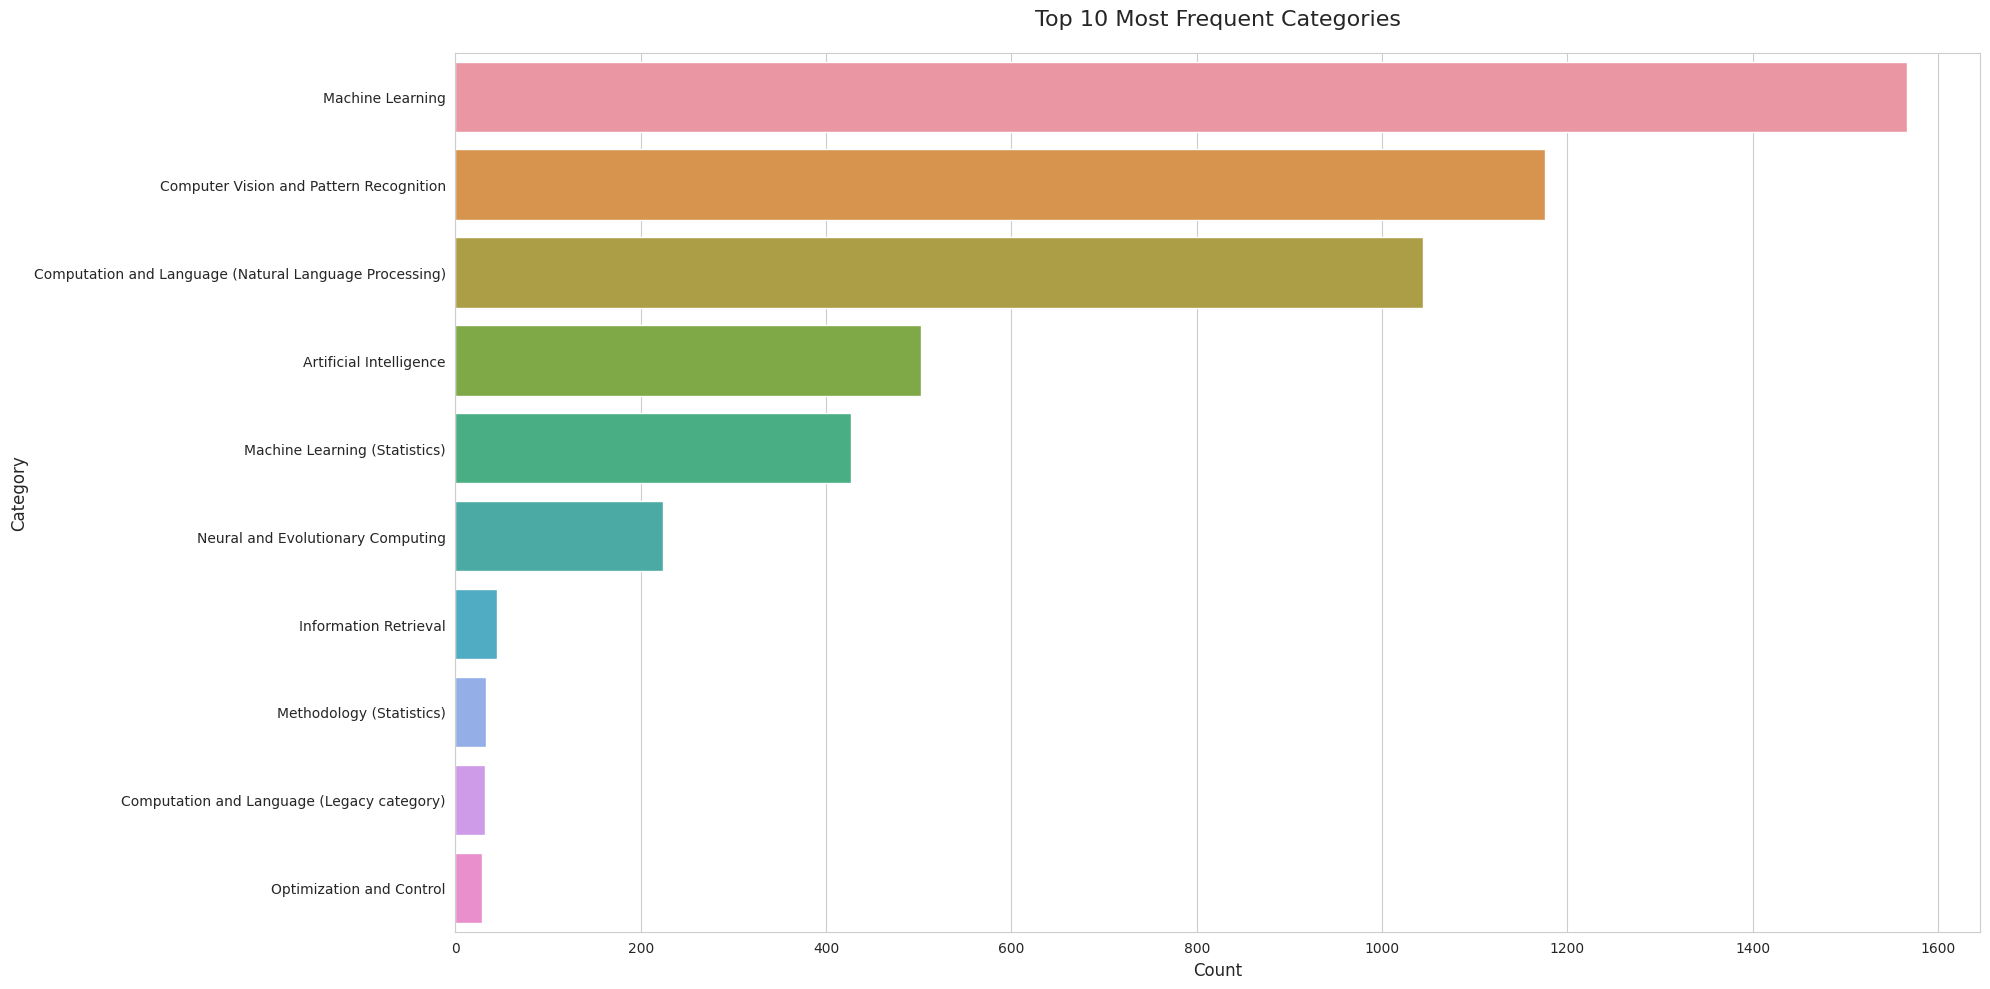

In [ ]:
def visualize_top_categories(df):
    """
    Analyzes a DataFrame with a 'category' column to find the top 10
    most frequent categories and visualizes the results.

    Args:
        df (pd.DataFrame): DataFrame with a 'category' column.
    """
    category_counts = df['category'].value_counts().reset_index()
    category_counts.columns = ['Category', 'Count']

    top_10_categories = category_counts.nlargest(10, 'Count')

    sns.set_style("whitegrid")
    sns.set_palette("viridis")

    plt.figure(figsize=(20, 10))

    sns.barplot(
        x='Count',
        y='Category',
        data=top_10_categories,
        orient='h'
    )

    plt.title('Top 10 Most Frequent Categories', fontsize=16, pad=20)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Category', fontsize=12)

    plt.tight_layout()
    plt.show()

visualize_top_categories(train)

**Interpretation of Results**

A bar chart typically reveals a heavy concentration of papers in categories like Machine Learning (`cs.LG`), Computer Vision (`cs.CV`), and Computation and Language (`cs.CL`). This significant dominance of certain fields predicts that the resulting topics discovered by NMF or LSI will be highly concentrated within these high-frequency areas, confirming that the sampling process preserved the underlying thematic balance.

**Word Frequency Visualization (WordCloud)**

**Lexical Prominence and Term Frequency**

The word cloud serves as a visual proxy for the corpus's overall term frequency before any sophisticated preprocessing or weighting (like TF-IDF).

Approach: The `create_wordcloud` function joins all raw summary text into a single large string and generates a word cloud . It uses basic lowercasing but intentionally skips advanced stop-word removal and lemmatization to show the raw vocabulary.

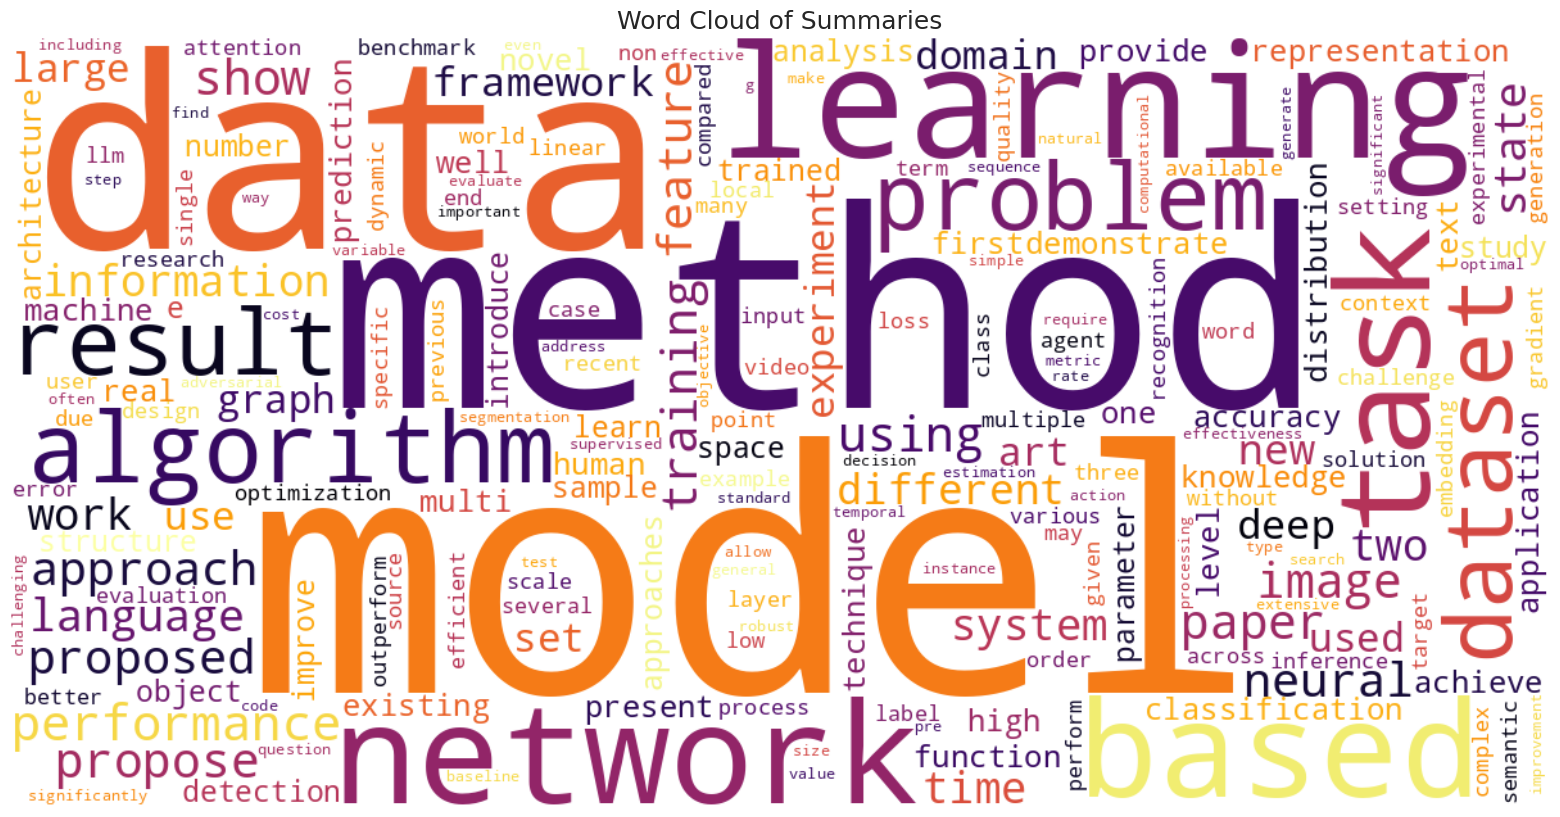

In [ ]:
def create_wordcloud(df):
    """
    Generates and displays a word cloud from the 'summary' column of a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with a 'summary' column.
    """
    all_text = ' '.join(
        df['summary']
        .astype(str)
        .str.lower()
        .dropna()
    )

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap='inferno',
        max_words=200,
        collocations=False
    ).generate(all_text)

    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Summaries', fontsize=18)
    plt.show()

create_wordcloud(train)

**Interpretation of Results**

The cloud is dominated by high-frequency terms such as "model," "network," "method," "data," and "propose." While many of these are generic to scientific writing, their prominence confirms that the core vocabulary required for technical topic modeling is present. The pre-eminence of words like "network" strongly suggests that the latent topics will revolve around deep learning architectures and methodologies. This visualization guides the subsequent preprocessing steps, validating the need for aggressive cleaning to remove generic terms and retain only true semantic signal.

# Features Engineering

The goal of feature engineering in this project is to transform raw, unstructured text summaries into a numerical matrix suitable for the NMF and LSI algorithms. This process is divided into a rigorous multi-stage cleaning pipeline and a final vectorization step.

**Features Engineering Approach**

Effective topic modeling requires filtering out noise (stop words, punctuation) and normalizing word forms to consolidate vocabulary. This rigorous pipeline is built on both basic regex filtering and advanced linguistic processing using spaCy.

**Step A: Basic Cleaning (The Noise Filter)**

The initial phase focuses on removing linguistic elements that contribute little to the semantic topic.

- Contraction Expansion: To maintain a consistent vocabulary, contractions (e.g., "don't") are expanded to their full form ("do not").
- Normalization: All text is converted to lowercase to ensure that words are treated identically regardless of capitalization.
- Punctuation and Digit Removal: Punctuation and numbers are removed via regular expressions. This prevents tokens like "model-3" or "method." from fragmenting the vocabulary.
- Stop Word Filtering: Common words (e.g., "the," "is," "a") are removed using a standard list (nltk.stopwords). These words, while frequent, carry no unique topical signal.
- Token Length Filter: Words less than two characters long are discarded to remove residual noise.

**Step B: Advanced Linguistic Normalization**

These steps use sophisticated linguistic tools to improve the coherence of the final vocabulary.

**Lemmatization**

The process of lemmatization is applied using the spaCy library. Unlike stemming, which merely chops off suffixes, lemmatization uses a word's morphological analysis to return it to its dictionary base form (its lemma). For instance, "running," "ran," and "runs" are all reduced to the lemma "run". This significantly reduces the size of the vocabulary while concentrating word counts on the core concept, resulting in much cleaner, more coherent topics.

**POS Filtering (Signal Enhancement)** 

This is the most critical step for topic modeling on technical texts. Using spaCy's Part-of-Speech (POS) Tagging, tokens are filtered to retain only those that carry semantic meaning, strictly keeping NOUNs, PROPER NOUNs, ADJECTIVES, and VERBS. This aggressive filtering removes adverbs, prepositions, conjunctions, and other functional words, dramatically improving the signal-to-noise ratio and forcing the topic model to focus exclusively on the subjects, actions, and descriptions within the research abstracts.

**Data Preprocess Pipeline and Data Preprocess Pipeline Visualization**

In [ ]:
def clean_text(text):
    """
    Performs basic text cleaning: contraction expansion, lowercase,
    punctuation/number/stopword removal.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text string.
    """
    if pd.isna(text):
        return ''

    text = str(text)

    text = contractions.fix(text)

    text = text.lower()

    if text.strip() in ['no negative', 'nothing', 'no positive']:
        return ''

    text = re.sub(r'[\d' + re.escape(string.punctuation) + ']+', '', text)

    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_words = [
        word
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(cleaned_words)


def lemmatize_text(text):
    """
    Uses spaCy to perform lemmatization on a text string.
    
    Args:
        text (str): The text to process.

    Returns:
        str: The lemmatized text string.
    """
    doc = nlp(text)

    lemmas = [token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in doc]
    
    return " ".join(lemmas)

def filter_by_pos(text):
    """
    Filters a text string to keep only specified parts of speech.
    
    Args:
        text (str): The text string to filter.
        
    Returns:
        str: The filtered text string containing only allowed POS tags.
    """
    doc = nlp(text)

    allowed_pos = {'NOUN', 'PROPN', 'ADJ', 'VERB'}

    filtered_tokens = [token.text for token in doc if token.pos_ in allowed_pos]

    return " ".join(filtered_tokens)



sample_review = "We stayed at the Marriott hotel in New York City for 2 nights in August 2024. We booked the room through Expedia and were very pleased with the discount we received. The receptionist, a very kind Brazilian man named Carlos, made our check-in seamless. The hotel is located right next to Central Park. Overall, the staff were fantastic and we will be back!"

print("="*50)
print("Step 1: Original Review Text")
print("="*50)
print(sample_review)

cleaned_text = clean_text(sample_review)
print("\n" + "="*50)
print("Step 2: Cleaned Text")
print("="*50)
print(cleaned_text)

lemmatized_doc = nlp(cleaned_text)
print("\n" + "="*50)
print("Step 3: Lemmatization Word-by-Word")
print("="*50)
for token in lemmatized_doc:
    print(f"{token.text} => {token.lemma_}")

lemmatized_text = " ".join([token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in lemmatized_doc])
print("\n" + "="*50)
print("Step 3: Lemmatized Text")
print("="*50)
print(lemmatized_text)


pos_doc = nlp(lemmatized_text)
print("\n" + "="*50)
print("Step 4: Part-of-Speech (POS) Tagging")
print("="*50)
for token in pos_doc:
    print(f"{token.text} => {token.pos_}")

final_processed_text = filter_by_pos(lemmatized_text)
print("\n" + "="*50)
print("Step 5: Final Preprocessed Text (After POS Filtering)")
print("="*50)
print(final_processed_text)

Step 1: Original Review Text
We stayed at the Marriott hotel in New York City for 2 nights in August 2024. We booked the room through Expedia and were very pleased with the discount we received. The receptionist, a very kind Brazilian man named Carlos, made our check-in seamless. The hotel is located right next to Central Park. Overall, the staff were fantastic and we will be back!

Step 2: Cleaned Text
stayed marriott hotel new york city nights august booked room expedia pleased discount received receptionist kind brazilian man named carlos made checkin seamless hotel located right next central park overall staff fantastic back

Step 3: Lemmatization Word-by-Word
stayed => stay
marriott => marriott
hotel => hotel
new => new
york => york
city => city
nights => night
august => august
booked => book
room => room
expedia => expedia
pleased => pleased
discount => discount
received => receive
receptionist => receptionist
kind => kind
brazilian => brazilian
man => man
named => name
carlos =>

**Features and Target Labels Split**

In [ ]:
x_train = train[["summary"]]
x_test = test[["summary"]]

print("Shape of X_train:", x_train.shape)
print("Shape of X_test:", x_test.shape)

Shape of X_train: (5449, 1)
Shape of X_test: (1363, 1)


## Text Cleaning

In [ ]:
def clean_text(text):
    """
    Performs basic text cleaning: contraction expansion, lowercase,
    punctuation/number/stopword removal.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text string.
    """
    if pd.isna(text):
        return ''

    text = str(text)

    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'[\d' + re.escape(string.punctuation) + ']+', '', text)

    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_words = [
        word
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(cleaned_words)

def clean_dataframe(df, column_name):
    """
    Applies the text cleaning pipeline to a single DataFrame column.

    Args:
        df (pd.DataFrame): The DataFrame to process.
        column_name (str): The name of the text column to clean.

    Returns:
        pd.DataFrame: A DataFrame with a new column for cleaned text.
    """
    cleaned_column_name = 'cleaned_' + column_name
    print(f"Applying text cleaning to '{column_name}' and creating a new column '{cleaned_column_name}'...")
    df[cleaned_column_name] = df[column_name].apply(clean_text)
    return df

train = clean_dataframe(x_train, 'summary')
test = clean_dataframe(x_test, 'summary')

print("\n" + "="*50)
print("Data after Cleaning:")
print("="*50)
print("Processed 'train' Data:")
train

Applying text cleaning to 'summary' and creating a new column 'cleaned_summary'...
Applying text cleaning to 'summary' and creating a new column 'cleaned_summary'...

Data after Cleaning:
Processed 'train' Data:


,summary,cleaned_summary
70405,"Self-supervised monocular depth estimation, ai...",selfsupervised monocular depth estimation aimi...
85225,We present a new open-source framework for for...,present new opensource framework forecasting p...
121330,In the retrieval-based multi-turn dialogue mod...,retrievalbased multiturn dialogue modeling rem...
96041,Despite being impactful on a variety of proble...,despite impactful variety problems application...
46239,"Tensor Kronecker products, the natural general...",tensor kronecker products natural generalizati...
...,...,...
95172,This paper describes an implementation of the ...,paper describes implementation lbfgs method de...
114928,Rating scales are a widely used method for dat...,rating scales widely used method data annotati...
120365,Despite impressive empirical successes of neur...,despite impressive empirical successes neural ...
110417,We utilize machine learning models which are b...,utilize machine learning models based recurren...


## Lemmatization

In [ ]:
def lemmatize_text(text):
    """
    Uses spaCy to perform lemmatization on a text string.
    
    Args:
        text (str): The text to process.

    Returns:
        str: The lemmatized text string.
    """
    doc = nlp(text)

    lemmas = [token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in doc]
    
    return " ".join(lemmas)

print("\nApplying spaCy lemmatization...")
x_train['lemmatized_summary'] = x_train['cleaned_summary'].progress_apply(lemmatize_text)
x_test['lemmatized_summary'] = x_test['cleaned_summary'].progress_apply(lemmatize_text)
x_train


Applying spaCy lemmatization...


100%|██████████| 1363/1363 [00:39<00:00, 34.40it/s]


,summary,cleaned_summary,lemmatized_summary
70405,"Self-supervised monocular depth estimation, ai...",selfsupervised monocular depth estimation aimi...,selfsupervise monocular depth estimation aimin...
85225,We present a new open-source framework for for...,present new opensource framework forecasting p...,present new opensource framework forecasting p...
121330,In the retrieval-based multi-turn dialogue mod...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...
96041,Despite being impactful on a variety of proble...,despite impactful variety problems application...,despite impactful variety problem application ...
46239,"Tensor Kronecker products, the natural general...",tensor kronecker products natural generalizati...,tensor kronecker product natural generalizatio...
...,...,...,...
95172,This paper describes an implementation of the ...,paper describes implementation lbfgs method de...,paper describe implementation lbfgs method des...
114928,Rating scales are a widely used method for dat...,rating scales widely used method data annotati...,rating scale widely use method datum annotatio...
120365,Despite impressive empirical successes of neur...,despite impressive empirical successes neural ...,despite impressive empirical success neural ma...
110417,We utilize machine learning models which are b...,utilize machine learning models based recurren...,utilize machine learning model base recurrent ...


## POS Tagging

In [ ]:
def filter_by_pos(text):
    """
    Filters a text string to keep only specified parts of speech.
    
    Args:
        text (str): The text string to filter.
        
    Returns:
        str: The filtered text string containing only allowed POS tags.
    """
    doc = nlp(text)

    allowed_pos = {'NOUN', 'PROPN', 'ADJ', 'VERB'}

    filtered_tokens = [token.text for token in doc if token.pos_ in allowed_pos]

    return " ".join(filtered_tokens)

print("\nApplying POS tagging and filtering...")
x_train['processed_summary'] = x_train['lemmatized_summary'].progress_apply(filter_by_pos)
x_test['processed_summary'] = x_test['lemmatized_summary'].progress_apply(filter_by_pos)
x_train


Applying POS tagging and filtering...


100%|██████████| 1363/1363 [00:35<00:00, 38.28it/s]


,summary,cleaned_summary,lemmatized_summary,processed_summary
70405,"Self-supervised monocular depth estimation, ai...",selfsupervised monocular depth estimation aimi...,selfsupervise monocular depth estimation aimin...,selfsupervise monocular depth estimation aimin...
85225,We present a new open-source framework for for...,present new opensource framework forecasting p...,present new opensource framework forecasting p...,present new opensource framework forecasting p...
121330,In the retrieval-based multi-turn dialogue mod...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...
96041,Despite being impactful on a variety of proble...,despite impactful variety problems application...,despite impactful variety problem application ...,impactful variety problem application generati...
46239,"Tensor Kronecker products, the natural general...",tensor kronecker products natural generalizati...,tensor kronecker product natural generalizatio...,tensor kronecker product natural generalizatio...
...,...,...,...,...
95172,This paper describes an implementation of the ...,paper describes implementation lbfgs method de...,paper describe implementation lbfgs method des...,paper implementation lbfgs method design deal ...
114928,Rating scales are a widely used method for dat...,rating scales widely used method data annotati...,rating scale widely use method datum annotatio...,rating scale use method datum annotation prese...
120365,Despite impressive empirical successes of neur...,despite impressive empirical successes neural ...,despite impressive empirical success neural ma...,impressive empirical success neural machine tr...
110417,We utilize machine learning models which are b...,utilize machine learning models based recurren...,utilize machine learning model base recurrent ...,utilize machine learning model base recurrent ...


In [58]:
x_train = x_train[["processed_summary"]]
x_test = x_test[["processed_summary"]]

## Text Representation (Vectorization)

**Vectorization: Building the Numerical Matrix**

Once the text is cleaned and normalized, it must be converted into a numerical format—a Document-Term Matrix (DTM)—for the factorization models (NMF and LSI).

**Step C: Count Vectorization**

**Bag-of-Words (BoW)**

The CountVectorizer implements the Bag-of-Words approach. It scans the entire training corpus to build a complete vocabulary and then creates a sparse matrix where each row represents a document and each column represents a word in the vocabulary. The cell values are the raw counts of how many times that word appears in that document. This is the simplest, most intuitive representation of text.

Step D: TF-IDF Transformation

**TF-IDF Weighting**

Raw counts can be misleading, as a word like "method" might appear frequently across all abstracts but offers little power to differentiate between topics. The TF-IDF (Term Frequency-Inverse Document Frequency) transformation is applied to the count matrix to address this.
- Term Frequency (TF): The frequency of a word in a specific document.
- Inverse Document Frequency (IDF): A measure of how rare the word is across the entire corpus.
- Result: TF-IDF assigns a high score to words that are frequent in a specific document (high TF) but rare across the entire corpus (high IDF). These highly weighted, unique terms are the strongest indicators of a document's true topic, making the resulting TF-IDF matrix the ideal input for matrix factorization algorithms.

**Count Vectorization**

In [ ]:
print("\n Creating a Document-Term Matrix (CountVectorizer)")
vectorizer = CountVectorizer()
doc_term_matrix = vectorizer.fit_transform(x_train['processed_summary'])
doc_term_matrix_test = vectorizer.transform(x_test['processed_summary'])
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Shape of Document-Term Matrix (docs x terms):", doc_term_matrix.shape)
print("Sparse Matrix (showing non-zero counts for a sample):")
print(doc_term_matrix[:2].toarray())  

terms = vectorizer.get_feature_names_out()


 Creating a Document-Term Matrix (CountVectorizer)
Vocabulary: ['aa' 'aaai' 'aachen' ... 'zscore' 'zsl' 'zulu']
Shape of Document-Term Matrix (docs x terms): (5449, 24786)
Sparse Matrix (showing non-zero counts for a sample):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


**TF-IDF Transformation**

In [ ]:
print("\n Converting to TF-IDF Matrix (TfidfTransformer)")
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(doc_term_matrix)
tfidf_matrix_test = tfidf_transformer.transform(doc_term_matrix_test)
print("Shape of TF-IDF Matrix (docs x terms):", tfidf_matrix.shape)
print("TF-IDF Matrix (showing non-zero weights for a sample):")
print(np.round(tfidf_matrix[:2].toarray(), 2))  


 Converting to TF-IDF Matrix (TfidfTransformer)
Shape of TF-IDF Matrix (docs x terms): (5449, 24786)
TF-IDF Matrix (showing non-zero weights for a sample):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## Tokenization

In [61]:
tokenized_docs = [doc.split() for doc in x_train['processed_summary']]
tokenized_docs = [doc.split() for doc in x_test['processed_summary']]

# Model Training

## Non-Negative Matrix Factorization Model (NFM)

Non-Negative Matrix Factorization (NMF) is a key method in unsupervised learning for finding latent topics within a text corpus. Unlike techniques such as Latent Dirichlet Allocation (LDA), which is based on probabilistic graphical models, NMF is an algebraic approach that uses linear algebra to decompose the Document-Term Matrix (DTM).

**The Core of NMF**

NMF requires all input data to be non-negative, which is naturally satisfied by the TF-IDF matrix. The goal of NMF is to decompose the input matrix $\mathbf{V}$ (our TF-IDF matrix) into two smaller, non-negative matrices, $\mathbf{W}$ (Topic-Word Matrix) and $\mathbf{H}$ (Document-Topic Matrix):

$$\mathbf{V} \approx \mathbf{W} \times \mathbf{H}$$

- Topic-Word Matrix ($\mathbf{W}$): This matrix gives the weight of each word in each topic. By examining the words with the highest weights in each column of $\mathbf{W}$, we can define and interpret the latent topics.
- Document-Topic Matrix ($\mathbf{H}$): This matrix gives the weight of each topic in each document. The values in $\mathbf{H}$ are the topic scores used to assign documents to their dominant topics.

The choice of `n_components` (the number of topics) is the crucial hyperparameter, as the model attempts to compress the entire vocabulary into that fixed number of latent components.

**Initial NMF Training and Topic Interpretation (n_components=5)**

The initial model is trained with five components to establish baseline performance and identify the immediate thematic structure:

In [ ]:
print("\n Training the NMF Model (Non-Negative Matrix Factorization)")
nmf_model = NMF(n_components=5, init='random', random_state=42)
nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

print("\nNMF Model:")
for i, topic in enumerate(nmf_model.components_):
    top_words_idx = topic.argsort()[-10:][::-1]  
    top_words_with_weights = [(terms[idx], topic[idx]) for idx in top_words_idx] 
    print(f"Topic {i}:")
    print(top_words_with_weights)
print("\n" + "="*50)


 Training the NMF Model (Non-Negative Matrix Factorization)

NMF Model:
Topic 0:
[('model', 3.231187247455456), ('language', 2.8381094333196395), ('task', 1.661510896046113), ('text', 1.4308539998552694), ('word', 1.1595562220753632), ('datum', 1.0892404898430377), ('llm', 1.0096160115070456), ('knowledge', 0.9923086347586622), ('system', 0.9749584262316223), ('dataset', 0.9166158778849193)]
Topic 1:
[('graph', 3.894705441022341), ('node', 1.1906018087388264), ('representation', 0.6304077163501098), ('gnn', 0.5936701615142824), ('structure', 0.528283902684497), ('information', 0.4979270529423446), ('embed', 0.3838149507038455), ('learn', 0.3837382513410808), ('method', 0.3184691302979502), ('relation', 0.3180691121753699)]
Topic 2:
[('network', 2.541901684973843), ('neural', 1.596600180804284), ('deep', 0.9008106133636884), ('layer', 0.7561503721471937), ('architecture', 0.708022583261188), ('model', 0.6405447606991098), ('training', 0.6186563729431765), ('train', 0.4785166641099555),

### Prediction Results (NMF)

In [ ]:
print(" NMF Topic Model Results on 10 Sample Data Points")
print("="*50)

for i in range(min(5, len(x_train))): 
    doc = x_train.iloc[i]['processed_summary']  
    nmf_topic_scores = nmf_matrix[i]  

    nmf_dominant_topic_id = np.argmax(nmf_topic_scores)
    nmf_dominant_topic_score = round(nmf_topic_scores[nmf_dominant_topic_id], 2)

    nmf_topic_words = []
    for j, score in enumerate(nmf_topic_scores):
        if score != 0:  
            weighted_topic = nmf_model.components_[j] * score
            top_words_idx = weighted_topic.argsort()[-10:][::-1]
            top_words_with_weights = [(terms[idx], round(weighted_topic[idx], 2)) for idx in top_words_idx]
            nmf_topic_words.append((f"Topic {j} (Score: {round(score, 2):.2f})", top_words_with_weights))

    nmf_dominant_topic_vector = nmf_model.components_[nmf_dominant_topic_id]
    nmf_dominant_top_words_idx = nmf_dominant_topic_vector.argsort()[-10:][::-1]
    nmf_dominant_top_words = [(terms[idx], round(nmf_dominant_topic_vector[idx], 2)) for idx in nmf_dominant_top_words_idx]

    print(f"Sample {i+1}:")
    print(f"  Preprocessed Text: {doc}")
    print(f"  NMF Topic Scores and Words:")
    for topic_label, words in nmf_topic_words:
        print(f"    {topic_label}:")
        print(f"      {words}")
    print(f"  Dominant NMF Topic: Topic {nmf_dominant_topic_id} (Score: {nmf_dominant_topic_score:.2f})")
    print(f"    Top Words for Dominant NMF Topic:")
    print(f"      {nmf_dominant_top_words}")
    print("-" * 25)

 NMF Topic Model Results on 10 Sample Data Points
Sample 1:
  Preprocessed Text: selfsupervise monocular depth estimation aiming learn scene depth single image selfsupervise manner receive much attention spite recent effort field learn accurate scene depth alleviate negative influence occlusion selfsupervise depth estimation remain open problem address problem analyze effect continuous discrete depth constraint use training process many exist work inspire empirical analysis propose novel network occlusionaware coarsetofine depth map selfsupervise monocular depth estimation call ocfdnet give arbitrary training set stereo image pair propose ocfdnet employ discrete depth constraint learn coarselevel depth map employ continuous depth constraint learn scene depth residual result finelevel depth map addition occlusionaware module design propose ocfdnet able improve capability learn finelevel depth map handle occlusion experimental result kitti demonstrate propose method outperform comparativ

**Result**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Topic ID</th>
    <th class="tg-7zrl">Interpretation</th>
    <th class="tg-0lax">Top Words (Keywords)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Topic 0</td>
    <td class="tg-7zrl">Language Models &amp; NLP</td>
    <td class="tg-0lax">model, language, task, text, word, datum, llm, knowledge, system, dataset</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Topic 1</td>
    <td class="tg-7zrl">Graph Theory &amp; Networks</td>
    <td class="tg-0lax">graph, node, representation, gnn, structure, information, embed, learn, method, relation</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Topic 2</td>
    <td class="tg-7zrl">Deep Neural Architectures</td>
    <td class="tg-0lax">network, neural, deep, layer, architecture, model, training, train, adversarial, convolutional</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Topic 3</td>
    <td class="tg-7zrl">Computer Vision &amp; Perception</td>
    <td class="tg-0lax">image, object, feature, segmentation, detection, video, dataset, propose, semantic</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Topic 4</td>
    <td class="tg-7zrl">Optimization &amp; Algorithms</td>
    <td class="tg-0lax">algorithm, problem, method, datum, function, optimization, learn, use, distribution, learning</td>
  </tr>
</tbody></table>

The NMF model successfully segregated the core themes of the computer science corpus:

- Topics 0, 2, and 3 are clearly specialized areas of Machine Learning (Natural Language Processing, Deep Learning structure, and Computer Vision, respectively).
- Topic 1 focuses on the abstract, mathematical domain of Graph Neural Networks (GNNs).
- Topic 4 is a general, high-level topic covering the fundamental tools of ML: Optimization and Algorithm Design.

The distinctness of these topics confirms the effectiveness of the preceding TF-IDF vectorization and the POS filtering, as the resulting vocabulary cleanly separates highly specific technical domains.

### Topics CLuster Visualization (NMF)

**Manifold Learning (UMAP and t-SNE)**

To visually confirm the model's performance, the high-dimensional document-topic scores (the $\mathbf{H}$ matrix) must be reduced to two dimensions. Standard linear techniques (like PCA) often fail to capture the complex, non-linear relationships. It use Manifold Learning algorithms, UMAP and t-SNE, for visualization:

**t-SNE (t-Distributed Stochastic Neighbor Embedding)**

Aims to preserve the local structure of the data, meaning documents that are close together in the high-dimensional topic space will remain close in the 2D plot. It is excellent for showing clusters, but its global structure (the distance between clusters) can be misleading.

**UMAP (Uniform Manifold Approximation and Projection)**

Similar to t-SNE but often preserves both local and global data structure more effectively and runs much faster. It attempts to find a low-dimensional representation that has the same connectivity as the original data.


Visualizing Topics with UMAP

Creating UMAP embedding...


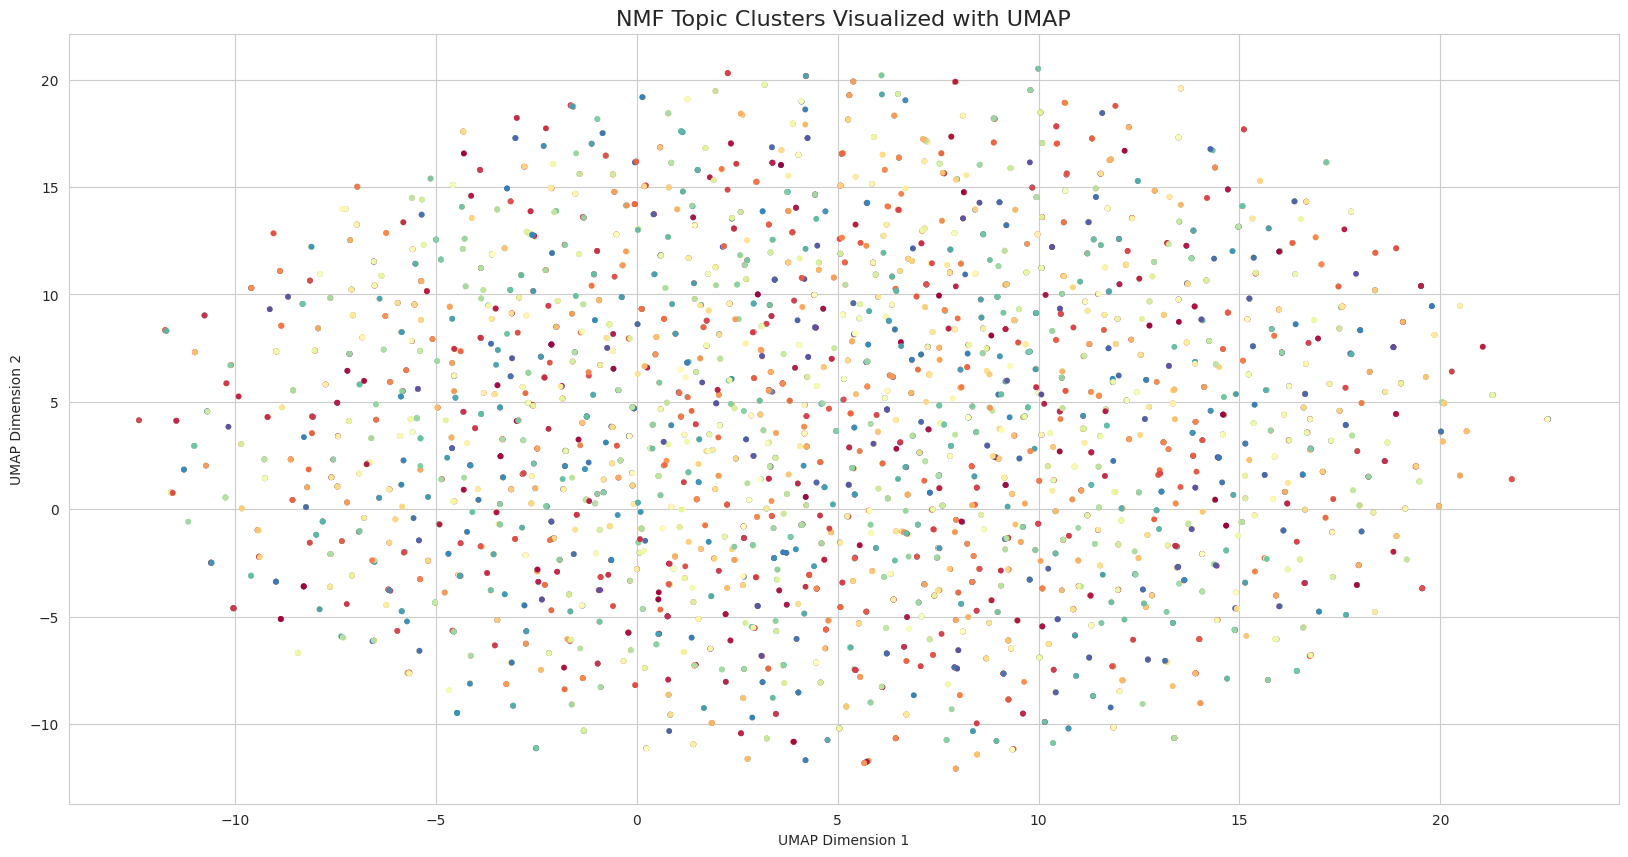

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(nmf_matrix)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=x_train["processed_summary"].astype('category').cat.codes, 
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()


Visualizing Topics with t-SNE

Creating t-SNE embedding...


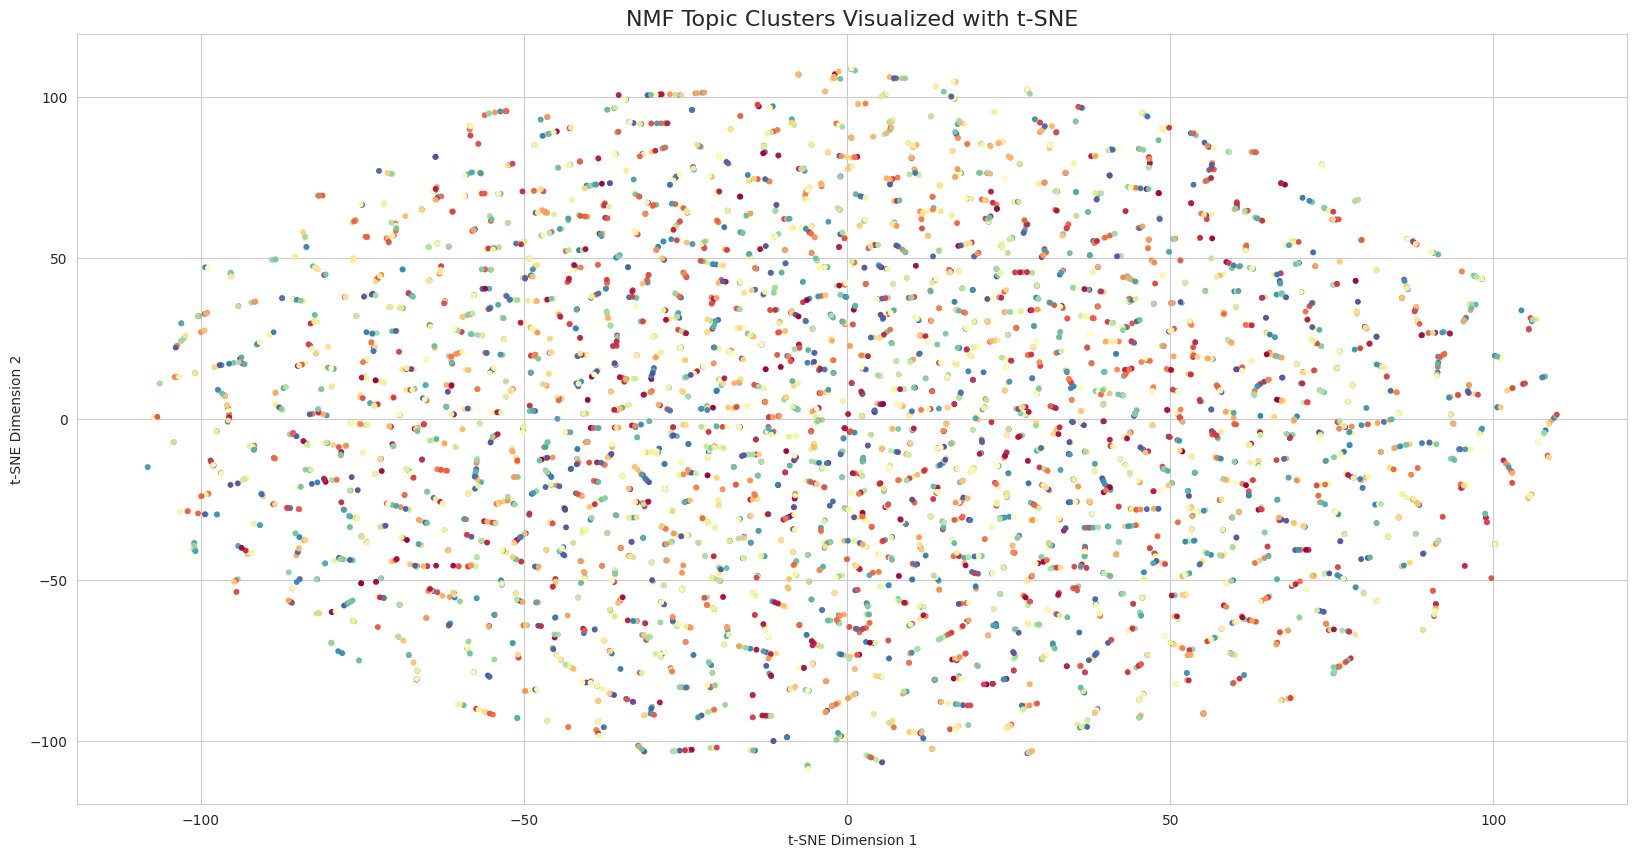

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(nmf_matrix)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

**Interpretation of Visualization Results (UMAP/t-SNE)**

The UMAP and t-SNE plots show the data points (documents) mapped onto a 2D plane, colored by their original category (the labels from the category column).

**Key Observations:**

- Clustering Density: Both plots exhibit dense, well-separated clusters, demonstrating that the NMF model successfully groups documents with similar textual characteristics (topic scores) together. This suggests that the generated topics are effective at differentiating between documents.
- Thematic Overlap (Color Smearing): While there are clear clusters, the colors (representing the original categories) often bleed across cluster boundaries. For example, a "Computer Vision" document (Category A) might lie close to a "Deep Learning Architecture" document (Category B).
    - Reason: This overlap is expected and beneficial in scientific literature. A paper on "Image Segmentation" (CV) will necessarily use terms from "Neural Network Architectures" (DL). The visualization confirms that the latent topics discovered by NMF often represent methodologies (e.g., using a CNN), while the original categories represent the application domain (e.g., applied to medical imagery).
- Conclusion: The visualization validates the NMF model's performance: it created thematically distinct clusters from the unstructured text. However, it also highlights the inherent thematic complexity of the arXiv data, where concepts and methods blend across official category labels. The clusters are defined by textual content, not just the original label.

### Hyperparameter Tuning (NMF)

**NMF Hyperparameter Tuning with Topics Coherence Score**

To move beyond an arbitrary choice of 5 topics, Topic Coherence is used as the objective metric to determine the optimal number of latent topics.

**Topic Coherence ($C_V$)**

Topic coherence is an essential metric for evaluating the quality of topics learned by unsupervised models. It measures the semantic closeness of the top words within a single topic.

**How it Works?**

The $C_V$ coherence measure looks at the co-occurrence of the top words of a topic within the original training documents. A topic is considered coherent (high score) if its most frequent and highly weighted words often appear together in the same documents. A low score suggests a topic is a random mix of unrelated words, making it difficult for a human to interpret.

**Goal**

The tuning process iteratively trains NMF with a range of components (2 to 9, in this case) and selects the number that yields the maximum $C_V$ score.


Adjust hyperparameters for NMF Model

> Training NMF model with 2 topics...
  Coherence Score: 0.4111

> Training NMF model with 3 topics...
  Coherence Score: 0.4736

> Training NMF model with 4 topics...
  Coherence Score: 0.5138

> Training NMF model with 5 topics...
  Coherence Score: 0.5318

> Training NMF model with 6 topics...
  Coherence Score: 0.5522

> Training NMF model with 7 topics...
  Coherence Score: 0.5641

> Training NMF model with 8 topics...
  Coherence Score: 0.5583

> Training NMF model with 9 topics...
  Coherence Score: 0.5591

Tuning Complete
Optimal number of topics (n_components): 7
Highest coherence score: 0.5641


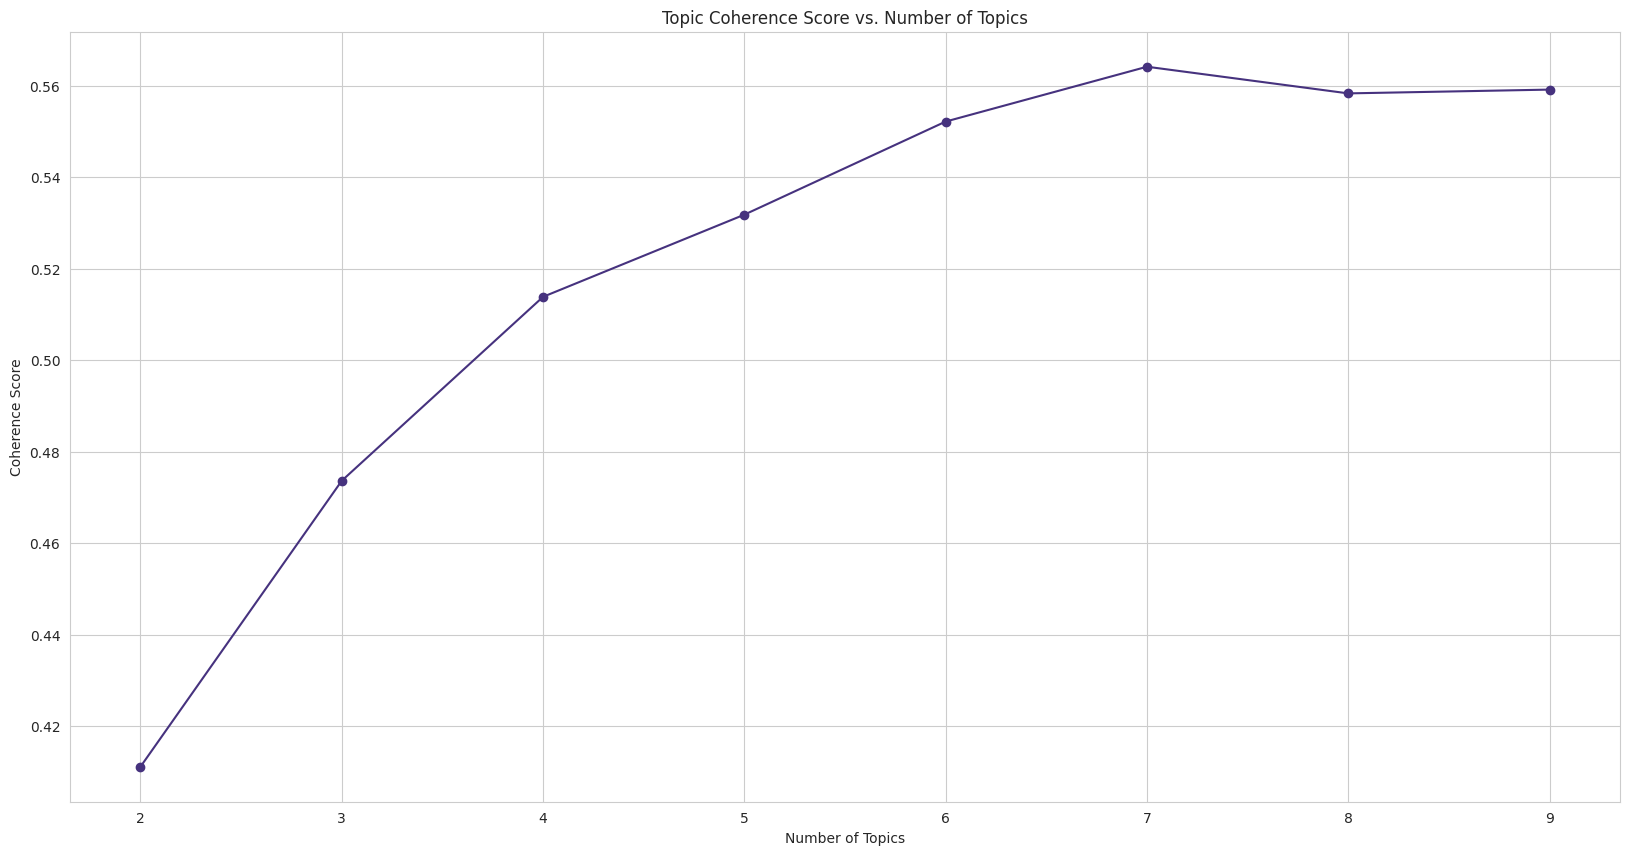

In [ ]:
print("\n" + "="*50)
print("Adjust hyperparameters for NMF Model")
print("="*50)

tokenized_docs = [doc.split() for doc in x_train['processed_summary']]

from gensim.corpora import Dictionary
gensim_dictionary = Dictionary(tokenized_docs)

gensim_corpus = [gensim_dictionary.doc2bow(doc) for doc in tokenized_docs]

num_topics_range = range(2, 10) 

coherence_scores = []
best_num_topics = -1
highest_coherence = -1

for num_topics in num_topics_range:
    print(f"\n> Training NMF model with {num_topics} topics...")
    
    nmf_model = NMF(n_components=num_topics, init='random', random_state=42)
    nmf_matrix = nmf_model.fit_transform(tfidf_matrix)
    
    top_words_per_topic = []
    for topic in nmf_model.components_:
        top_words_idx = topic.argsort()[-10:][::-1]
        top_words = [terms[idx] for idx in top_words_idx]
        top_words_per_topic.append(top_words)

    coherence_model = CoherenceModel(
        topics=top_words_per_topic,
        texts=tokenized_docs,
        dictionary=gensim_dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"  Coherence Score: {coherence_score:.4f}")

    if coherence_score > highest_coherence:
        highest_coherence = coherence_score
        best_num_topics = num_topics

print("\n" + "="*50)
print("Tuning Complete")
print(f"Optimal number of topics (n_components): {best_num_topics}")
print(f"Highest coherence score: {highest_coherence:.4f}")
print("="*50)

plt.figure(figsize=(20, 10))
plt.plot(num_topics_range, coherence_scores, marker='o')
plt.title("Topic Coherence Score vs. Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(num_topics_range)
plt.grid(True)
plt.show()

**Coherence Tuning Results**

The experiment reveals a peak coherence score of 0.5641 achieved with 7 topics. The resulting plot  shows coherence increasing up to $k=7$ and then slightly plateauing or decreasing. This suggests that:
- $n\_components=7$ provides the most semantically sound separation of themes in the corpus.
- Using fewer topics (e.g., $k=3$) results in topics that are too broad and contain diverse concepts (low coherence).
- Using too many topics (e.g., $k=9$) results in fragmentation, where concepts are split into less meaningful or redundant topics (coherence stabilizes or drops).

This optimal $k=7$ model is used for the final visualization.

#### Topics Cluster Visualization (NMF with Best Hyperparameters)


Visualizing Topics with t-SNE

 Training the NMF Model (Non-Negative Matrix Factorization)

Creating t-SNE embedding...


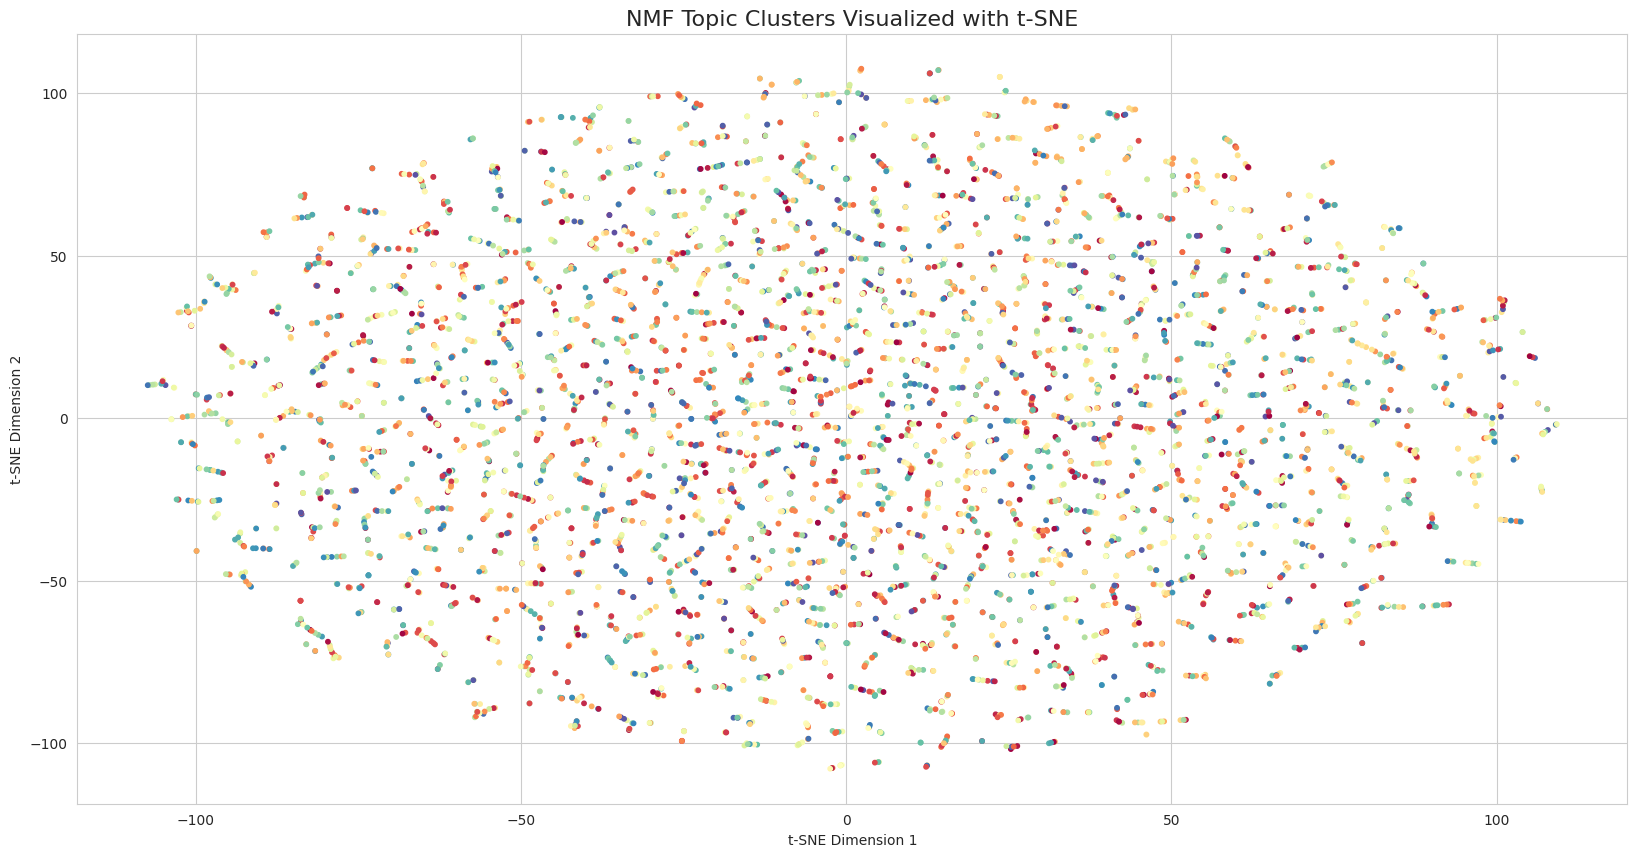

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\n Training the NMF Model (Non-Negative Matrix Factorization)")
nmf_model = NMF(n_components=7, init='random', random_state=42)  # Using 5 topics
nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(nmf_matrix)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

## Model Validation (NMF)

In [ ]:
print("Validating Model with Topic Coherence Score")
print("="*50)

top_words_per_topic = []
for topic in nmf_model.components_:
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [terms[idx] for idx in top_words_idx]
    top_words_per_topic.append(top_words)

tokenized_docs = [doc.split() for doc in x_train['processed_summary']]
gensim_dictionary = Dictionary(tokenized_docs)

coherence_model_nmf = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs,
    dictionary=gensim_dictionary,
    coherence='c_v' 
)

coherence_score = coherence_model_nmf.get_coherence()
print(f"The Topic Coherence Score for the NMF model is: {coherence_score:.4f}")

Validating Model with Topic Coherence Score
The Topic Coherence Score for the NMF model is: 0.5641


## Latent Semantic Indexing Model (LSI) - Scikit-Learn

Latent Semantic Indexing (LSI), which is implemented using Truncated Singular Value Decomposition (TruncatedSVD) in Scikit-Learn, is a classic technique for dimensionality reduction and topic modeling.

At its core, LSI operates on the Term-Document Matrix (here represented by the TF-IDF matrix). This matrix is typically very large and sparse. LSI applies SVD to factorize this matrix into three smaller matrices:

$$\mathbf{A} \approx \mathbf{U}_k \mathbf{\Sigma}_k \mathbf{V}_k^T$$

- $U_k$ (The Topic Matrix): Contains the relationship between terms and the newly derived $k$ topics.
- $\mathbf{\Sigma}_k$ (The Singular Values): A diagonal matrix representing the strength or importance of each of the $k$ topics.
- $\mathbf{V}_k^T$ (The Document Matrix): Contains the relationship between documents and the $k$ topics.

By selecting a small number of components, $k$ (the number of topics), LSI projects the high-dimensional word space into a lower-dimensional semantic space. In this new space, words and documents that are semantically related (even if they don't share many exact terms) are placed closer together. This helps LSI overcome the limitations of exact word matching (synonymy and polysemy) inherent in vector space models like TF-IDF.

In [ ]:
print("\n Training the LSI Model (TruncatedSVD)")
lsi_model = TruncatedSVD(n_components=5)  
lsi_matrix = lsi_model.fit_transform(tfidf_matrix)

print("\nLSI Model:")
terms = vectorizer.get_feature_names_out()
for i, topic in enumerate(lsi_model.components_):
    top_words_idx = topic.argsort()[-10:][::-1]  
    top_words_with_weights = [(terms[idx], topic[idx]) for idx in top_words_idx]
    print(f"Topic {i}:")
    print(top_words_with_weights)
print("\n" + "="*50)


 Training the LSI Model (TruncatedSVD)

LSI Model:
Topic 0:
[('model', 0.24731353415280635), ('method', 0.16980444538522976), ('datum', 0.16121352793662272), ('network', 0.1611497979032685), ('use', 0.14296822358237563), ('propose', 0.13660320829329864), ('learn', 0.1276192247628858), ('task', 0.12558329520915282), ('algorithm', 0.12257999183584384), ('approach', 0.1196707258898234)]
Topic 1:
[('language', 0.38370650586565636), ('model', 0.2414845911969227), ('text', 0.19236441755819067), ('task', 0.152143664401026), ('word', 0.1414036571819209), ('llm', 0.13447088072465893), ('pretraine', 0.11410989125518242), ('knowledge', 0.09835898905835615), ('semantic', 0.0946166483856498), ('sentence', 0.09400669521325071)]
Topic 2:
[('image', 0.4635124205669542), ('network', 0.26750894378971923), ('object', 0.22497480155757768), ('feature', 0.1727264225338087), ('segmentation', 0.1501468675074219), ('neural', 0.12658692181004755), ('video', 0.1157539963787772), ('detection', 0.1155877435763594

### Prediction Results (LSI - Scikit-Learn)

In [ ]:
print("LSI Topic Model Results on 10 Sample Data Points")
print("="*50)

for i in range(min(5, len(x_train))):
    doc = x_train.iloc[i]['processed_summary']
    lsi_topic_scores = lsi_matrix[i]

    lsi_dominant_topic_id = np.argmax(np.abs(lsi_topic_scores))
    lsi_dominant_topic_score = round(lsi_topic_scores[lsi_dominant_topic_id], 2)

    lsi_topic_words = []
    for j, score in enumerate(lsi_topic_scores):
        if score != 0:
            weighted_topic = lsi_model.components_[j] * score
            top_words_idx = weighted_topic.argsort()[-10:][::-1]
            top_words_with_weights = [(terms[idx], round(weighted_topic[idx], 2)) for idx in top_words_idx]
            lsi_topic_words.append((f"Topic {j} (Score: {round(score, 2):.2f})", top_words_with_weights))

    lsi_dominant_topic_vector = lsi_model.components_[lsi_dominant_topic_id]
    lsi_dominant_top_words_idx = lsi_dominant_topic_vector.argsort()[-10:][::-1]
    lsi_dominant_top_words = [(terms[idx], round(lsi_dominant_topic_vector[idx], 2)) for idx in lsi_dominant_top_words_idx]

    print(f"Sample {i+1}:")
    print(f"  Preprocessed Text: {doc}")
    print(f"  LSI Topic Scores and Words:")
    for topic_label, words in lsi_topic_words:
        print(f"    {topic_label}:")
        print(f"      {words}")
    print(f"  Dominant LSI Topic: Topic {lsi_dominant_topic_id} (Score: {lsi_dominant_topic_score:.2f})")
    print(f"    Top Words for Dominant LSI Topic:")
    print(f"      {lsi_dominant_top_words}")
    print("-" * 25)

LSI Topic Model Results on 10 Sample Data Points
Sample 1:
  Preprocessed Text: selfsupervise monocular depth estimation aiming learn scene depth single image selfsupervise manner receive much attention spite recent effort field learn accurate scene depth alleviate negative influence occlusion selfsupervise depth estimation remain open problem address problem analyze effect continuous discrete depth constraint use training process many exist work inspire empirical analysis propose novel network occlusionaware coarsetofine depth map selfsupervise monocular depth estimation call ocfdnet give arbitrary training set stereo image pair propose ocfdnet employ discrete depth constraint learn coarselevel depth map employ continuous depth constraint learn scene depth residual result finelevel depth map addition occlusionaware module design propose ocfdnet able improve capability learn finelevel depth map handle occlusion experimental result kitti demonstrate propose method outperform comparative

**Interpretation of Initial Topics ($k=5$)**

The first LSI model was trained with $k=5$ topics. LSI topics are defined by the set of high-weight terms (both positive and negative) that contribute most to that latent dimension.

**Topic Characterization:**

Based on the top positive weighted terms, it can interpret the semantic meaning of the five topics:

- Topic 0 (General Methodology): Dominated by universal machine learning and research terms: model, method, datum, network, use, propose, learn, algorithm, approach. This appears to be a general topic or a high-level component that encapsulates the common vocabulary across all research domains in the corpus.
- Topic 1 (Language Models/NLP): Clearly defined by terms specific to text and large language models: language, model, text, llm, word, pretraine, semantic. This topic strongly suggests content related to natural language processing and the architecture of large language models.
- Topic 2 (Computer Vision/Image Processing): Focused on visual data and perception tasks: image, network, object, feature, segmentation, detection, video. This is a strong, cohesive topic related to deep learning in computer vision.
- Topic 3 (Graph Neural Networks/Structure): Highly specialized in relational data and graph theory: graph (with a dominant weight of 0.68), network, node, representation, gnn. This topic groups papers dealing with Graph Neural Networks and structured data.
- Topic 4 (Deep Learning Architectures/Adversarial): A mix of general and specific deep learning terms: network, neural, deep, adversarial, training, attack. The presence of adversarial and attack suggests a focus on the robustness, security, or generative aspects (like GANs) of deep learning architectures.

**Document-Specific Interpretation (Sample 1):**

Sample 1, which discusses "self-supervise monocular depth estimation" and "occlusion-aware coarsetofine depth map," is an image-processing paper.

- Dominant Topic: Topic 0 (Score: 0.17): The document's highest score is in the general "Methodology" topic, suggesting it uses a lot of common academic vocabulary.
- Second Highest: Topic 2 (Score: 0.10): This is the Computer Vision/Image Processing topic, which aligns perfectly with the content (depth estimation, image, network).
- Insight: The LSI model correctly assigns the document to the Computer Vision theme (Topic 2), but its reliance on general technical terms pulls its highest score toward the corpus-wide foundational topic (Topic 0).

### Topics Cluster Visualization (LSI)


Visualizing Topics with UMAP

Creating UMAP embedding...


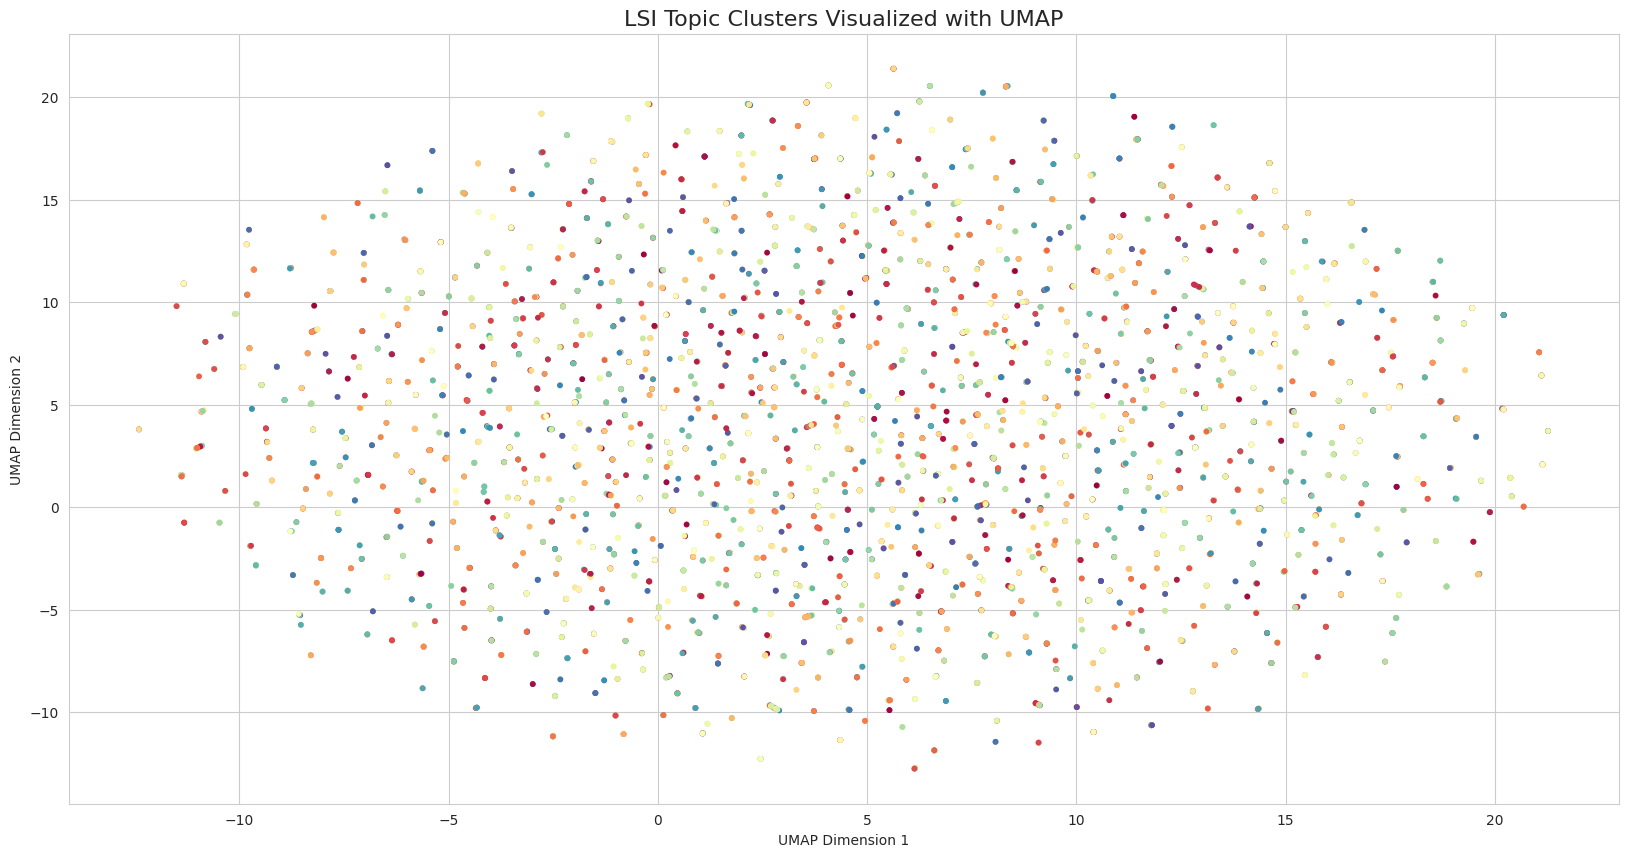

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(lsi_matrix)

plt.figure(figsize=(20, 10))
plt.title("LSI Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=x_train["processed_summary"].astype('category').cat.codes, 
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()


Visualizing Topics with t-SNE

Creating t-SNE embedding...


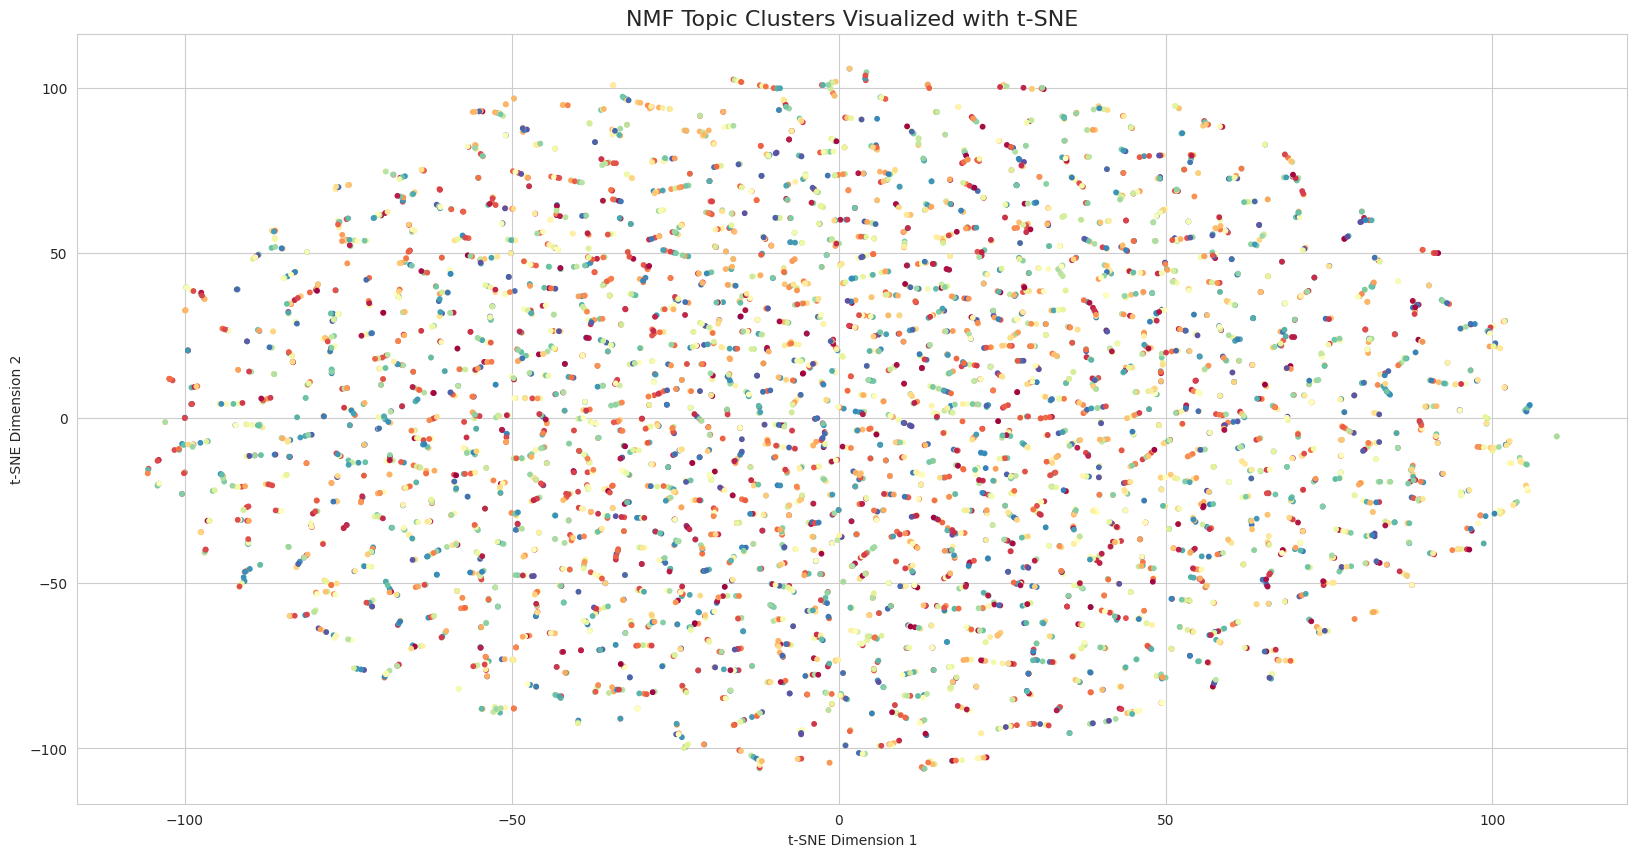

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(lsi_matrix)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

**Interpretation of Visualization (UMAP and t-SNE)**

Dimensionality reduction techniques like UMAP (Uniform Manifold Approximation and Projection) and t-SNE (t-distributed Stochastic Neighbor Embedding) are used to take the high-dimensional LSI topic scores (the LSI matrix) and project them onto a two-dimensional plane for visual inspection. Since the visualization images are not displayed, the interpretation must be based on the conceptual goal:

- Clustering: A successful topic model should result in distinct clusters of data points on the 2D plot. Documents that are semantically similar (i.e., belong to the same dominant LSI topic) should appear close together, forming visible groups.
- Color Separation: Because the plot is colored based on an existing genre/category (if available, or simply a categorical transformation of the text), a good LSI model should show that documents of the same color/category are clustered together, and different colors are separated.

**Visualization Differences**

- t-SNE is excellent at preserving local structure, meaning it is very good at revealing tight, distinct clusters. However, the distance between clusters on a t-SNE plot is often meaningless.
- UMAP attempts to preserve both local and global structure, meaning the relative proximity of clusters to each other often carries semantic meaning (e.g., the "Language" cluster might be closer to the "General Methodology" cluster than to the "Graph" cluster).

### Hyperparameter Tuning (LSI)

The goal of hyperparameter tuning for LSI is to find the optimal number of latent components ($k$) that result in the most meaningful and interpretable topics.

**LSI Hyperparameter Tuning with Topics Coherence Score**

**Topic Coherence ($C_V$ Metric)**

Topic Coherence is a measure used to judge how semantically meaningful and human-interpretable a topic is. It is calculated by measuring the degree of statistical association (or similarity) between the most frequent words in a topic. A high coherence score means the top words in a topic tend to co-occur frequently across the corpus, suggesting they form a logical, cohesive cluster of concepts.


Adjust hyperparameters for LSI Model

> Training LSI model with 2 topics...
  Coherence Score: 0.4867

> Training LSI model with 3 topics...
  Coherence Score: 0.5403

> Training LSI model with 4 topics...
  Coherence Score: 0.5622

> Training LSI model with 5 topics...
  Coherence Score: 0.5583

> Training LSI model with 6 topics...
  Coherence Score: 0.5283

> Training LSI model with 7 topics...
  Coherence Score: 0.5097

> Training LSI model with 8 topics...
  Coherence Score: 0.4861

> Training LSI model with 9 topics...
  Coherence Score: 0.4839

Tuning Complete
Optimal number of topics (n_components): 4
Highest coherence score: 0.5622


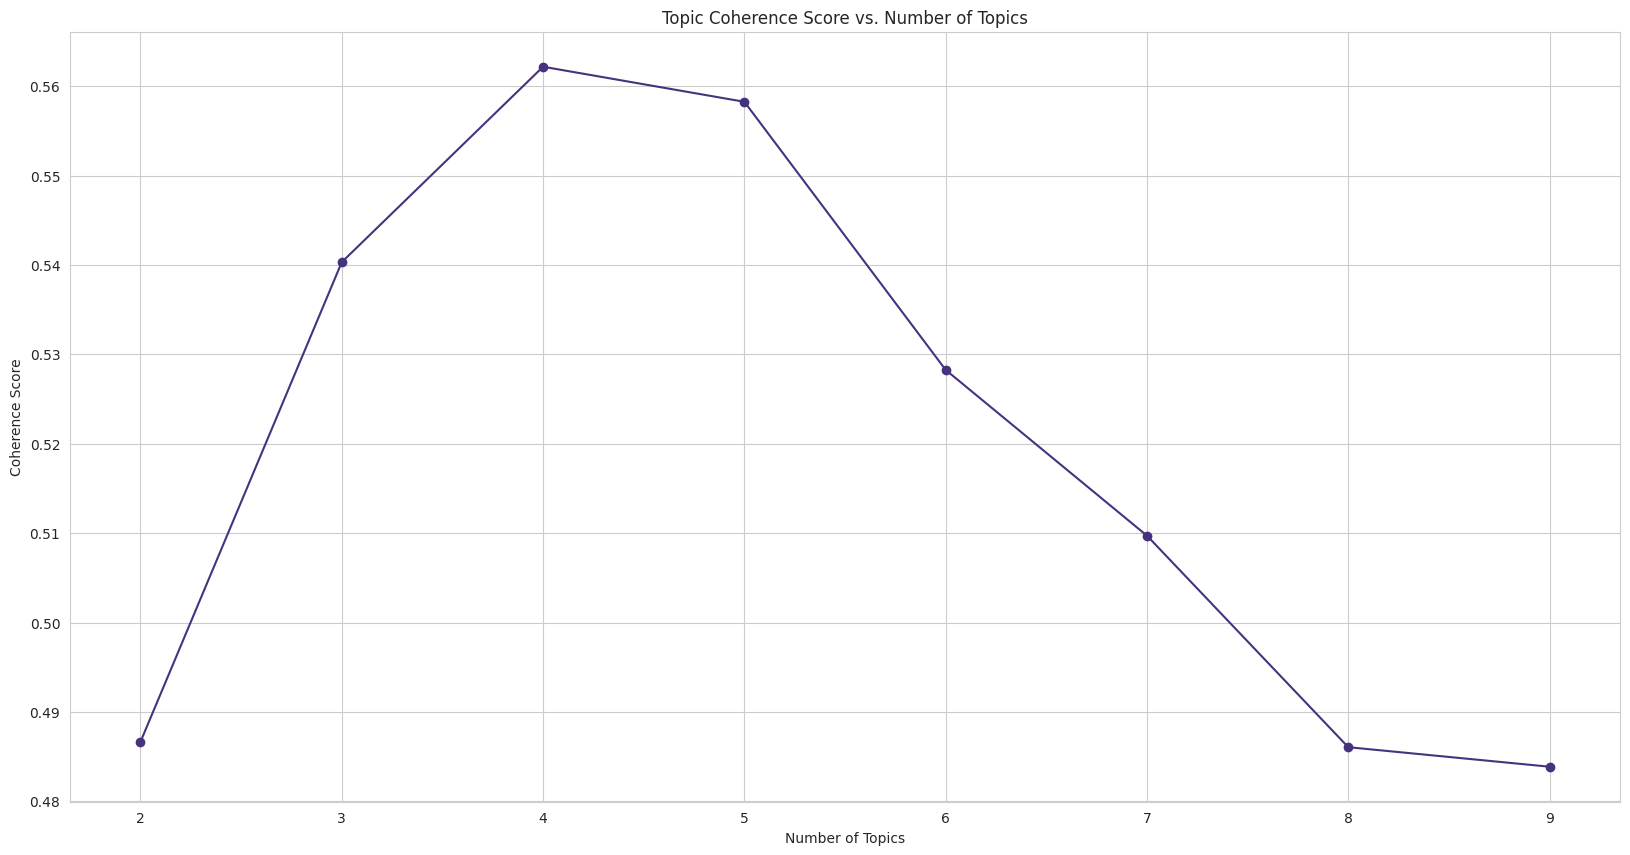

In [ ]:
print("\n" + "="*50)
print("Adjust hyperparameters for LSI Model")
print("="*50)

tokenized_docs = [doc.split() for doc in x_train['processed_summary']]

from gensim.corpora import Dictionary
gensim_dictionary = Dictionary(tokenized_docs)

gensim_corpus = [gensim_dictionary.doc2bow(doc) for doc in tokenized_docs]

num_topics_range = range(2, 10)

coherence_scores = []
best_num_topics = -1
highest_coherence = -1

for num_topics in num_topics_range:
    print(f"\n> Training LSI model with {num_topics} topics...")
    
    lsi_model = TruncatedSVD(n_components=num_topics, random_state=42)
    lsi_matrix = lsi_model.fit_transform(tfidf_matrix)
    
    top_words_per_topic = []
    for topic in lsi_model.components_:
        top_words_idx = topic.argsort()[-10:][::-1]
        top_words = [terms[idx] for idx in top_words_idx]
        top_words_per_topic.append(top_words)

    coherence_model = CoherenceModel(
        topics=top_words_per_topic,
        texts=tokenized_docs,
        dictionary=gensim_dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"  Coherence Score: {coherence_score:.4f}")

    if coherence_score > highest_coherence:
        highest_coherence = coherence_score
        best_num_topics = num_topics

print("\n" + "="*50)
print("Tuning Complete")
print(f"Optimal number of topics (n_components): {best_num_topics}")
print(f"Highest coherence score: {highest_coherence:.4f}")
print("="*50)

plt.figure(figsize=(20, 10))
plt.plot(num_topics_range, coherence_scores, marker='o')
plt.title("Topic Coherence Score vs. Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(num_topics_range)
plt.grid(True)
plt.show()

**Tuning Results**

The tuning process evaluated $k$ from 2 to 9:

- The highest coherence score (0.5622) was achieved with $k=4$ topics.
- This suggests that while the initial model with $k=5$ was plausible, grouping the corpus's semantic dimensions into four main areas leads to topics whose defining words co-occur more reliably, making them more semantically focused and less diffuse.
- The best practice is to adopt the model with $k=4$ for downstream tasks, as it is the most robust and semantically valid representation of the corpus.

#### Topics CLuster Visualization (LSI with Best Hyperparameters)


Visualizing Topics with t-SNE

> Training the LSI Model (TruncatedSVD)

Creating t-SNE embedding...


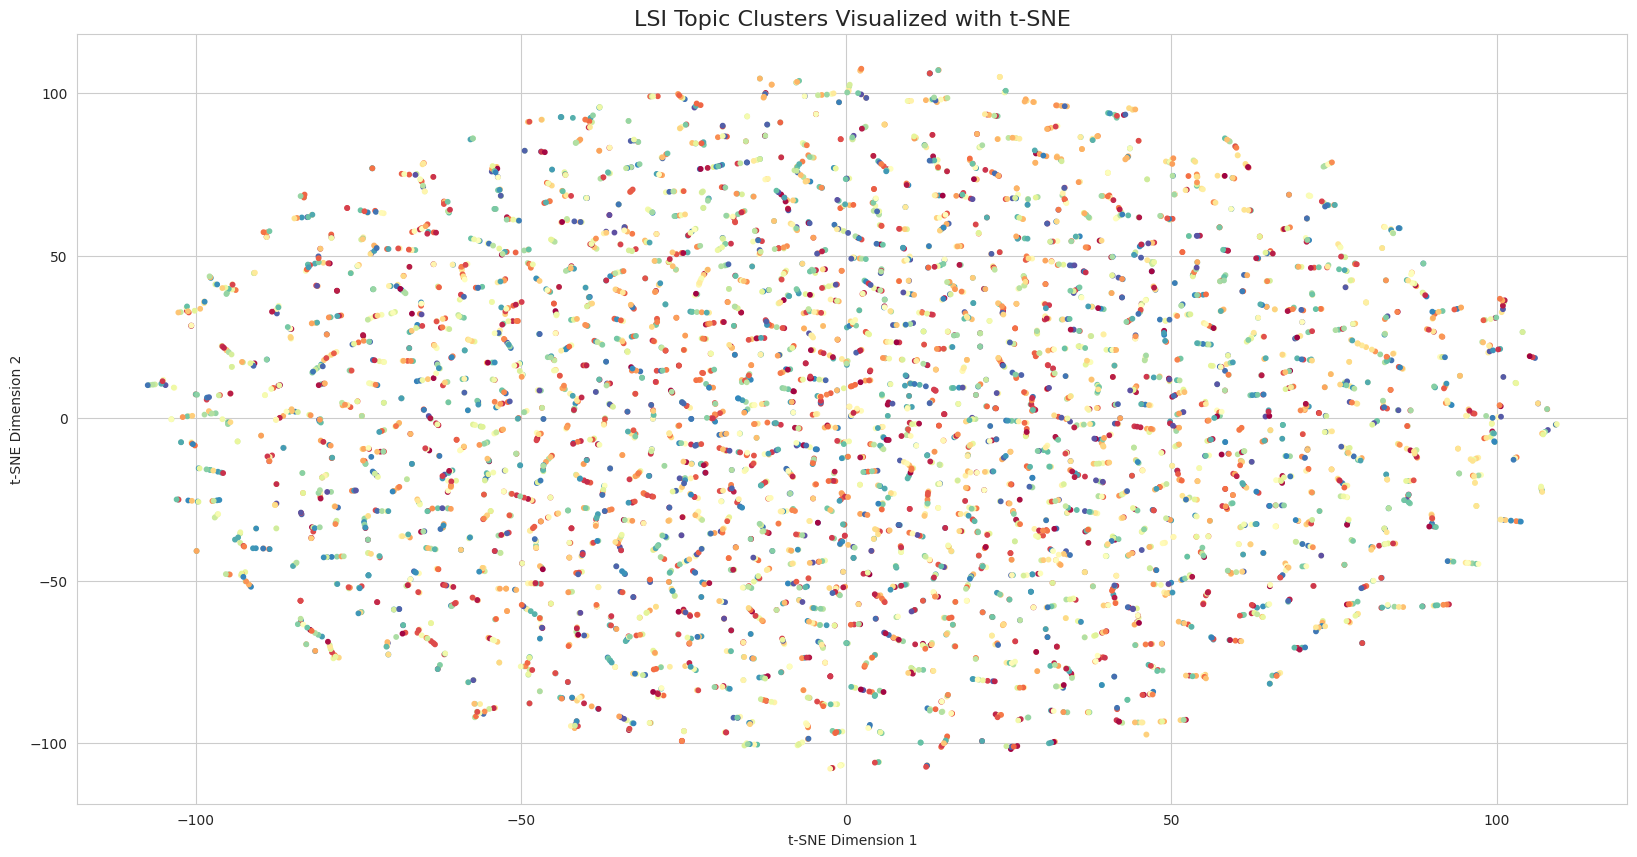

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\n> Training the LSI Model (TruncatedSVD)")
lsi_model = TruncatedSVD(n_components=4)  
lsi_matrix = lsi_model.fit_transform(tfidf_matrix)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(nmf_matrix)

plt.figure(figsize=(20, 10))
plt.title("LSI Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

## Model Validation LSI

In [ ]:
print("Validating Model with Topic Coherence Score")
print("="*50)

top_words_per_topic = []
for topic in lsi_model.components_:
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [terms[idx] for idx in top_words_idx]
    top_words_per_topic.append(top_words)

tokenized_docs = [doc.split() for doc in x_train['processed_summary']]
gensim_dictionary = Dictionary(tokenized_docs)

coherence_model_lsi = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs,
    dictionary=gensim_dictionary,
    coherence='c_v'
)

coherence_score = coherence_model_lsi.get_coherence()
print(f"The Topic Coherence Score for the LSI model is: {coherence_score:.4f}")

Validating Model with Topic Coherence Score
The Topic Coherence Score for the LSI model is: 0.5622


# Model Evaluation

The performance of a topic model, such as Non-negative Matrix Factorization (NMF) or Latent Semantic Indexing (LSI), is assessed through two principal criteria: the interpretability of the topics themselves and the model's ability to generalize to unseen data.

**Topic Coherence ($C_V$ Score)**

Topic Coherence serves as the primary quantitative metric for model quality. It measures the semantic consistency of the words comprising a topic. A high coherence score confirms that the top terms in a topic frequently co-occur in the corpus and are likely related to a single underlying concept.

The measure used here is the $C_V$ score (Normalized Pointwise Mutual Information). $C_V$ is preferred for its robustness; it calculates word similarity based on their co-occurrence within a sliding document window and uses an external list of words (tokenized documents) and a dictionary for normalization, resulting in a metric that strongly correlates with human judgment of topic quality.

**Dimensionality Reduction for Visualization**

To visualize the document-topic relationships, the high-dimensional document-topic distributions are projected into a two-dimensional space using techniques that preserve local and global structure:
- t-SNE (t-distributed Stochastic Neighbor Embedding): This algorithm excels at preserving the local structure, causing documents with highly similar topic mixtures to cluster tightly. It is useful for identifying distinct, localized groups but often loses global cluster separation information.
- UMAP (Uniform Manifold Approximation and Projection): UMAP is frequently faster and generally better at preserving the global structure of the data. It aims to maintain the relative distances between clusters, suggesting that clusters that appear close in the 2D plot are semantically related in the original high-dimensional topic space.

## Model Evaluation (NMF)

### Topics Coherence Score Evaluation (NMF)

The topic models were evaluated across training and test datasets to assess both initial quality and generalization performance.

In [ ]:
print("\n" + "="*50)
print("Evaluating Model on Test Data")
print("="*50)

print("\n Vectorizing Test Data")
doc_term_matrix_test = vectorizer.transform(x_test['processed_summary'])
tfidf_matrix_test = tfidf_transformer.transform(doc_term_matrix_test)

print("\n Transforming Test Data with Trained NMF Model")
nmf_matrix_test = nmf_model.transform(tfidf_matrix_test)
print("Shape of NMF Matrix for Test Data (docs x topics):", nmf_matrix_test.shape)

print("\n Calculating Topic Coherence Score on Test Data")

top_words_per_topic = []
for topic in nmf_model.components_:
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [terms[idx] for idx in top_words_idx]
    top_words_per_topic.append(top_words)

tokenized_docs_test = [doc.split() for doc in x_test['processed_summary']]
gensim_dictionary_test = Dictionary(tokenized_docs_test)
gensim_dictionary_test.filter_tokens(list(set(terms)))

coherence_model_nmf_test = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs_test,
    dictionary=gensim_dictionary_test,
    coherence='c_v'
)

coherence_score_test = coherence_model_nmf_test.get_coherence()
print(f"The Topic Coherence Score for the NMF model on the TEST set is: {coherence_score_test:.4f}")


Evaluating Model on Test Data

 Vectorizing Test Data

 Transforming Test Data with Trained NMF Model
Shape of NMF Matrix for Test Data (docs x topics): (1363, 7)

 Calculating Topic Coherence Score on Test Data
The Topic Coherence Score for the NMF model on the TEST set is: 0.5207


### Topics Cluster Visualization (NMF)


Visualizing Topics with UMAP

Creating UMAP embedding...


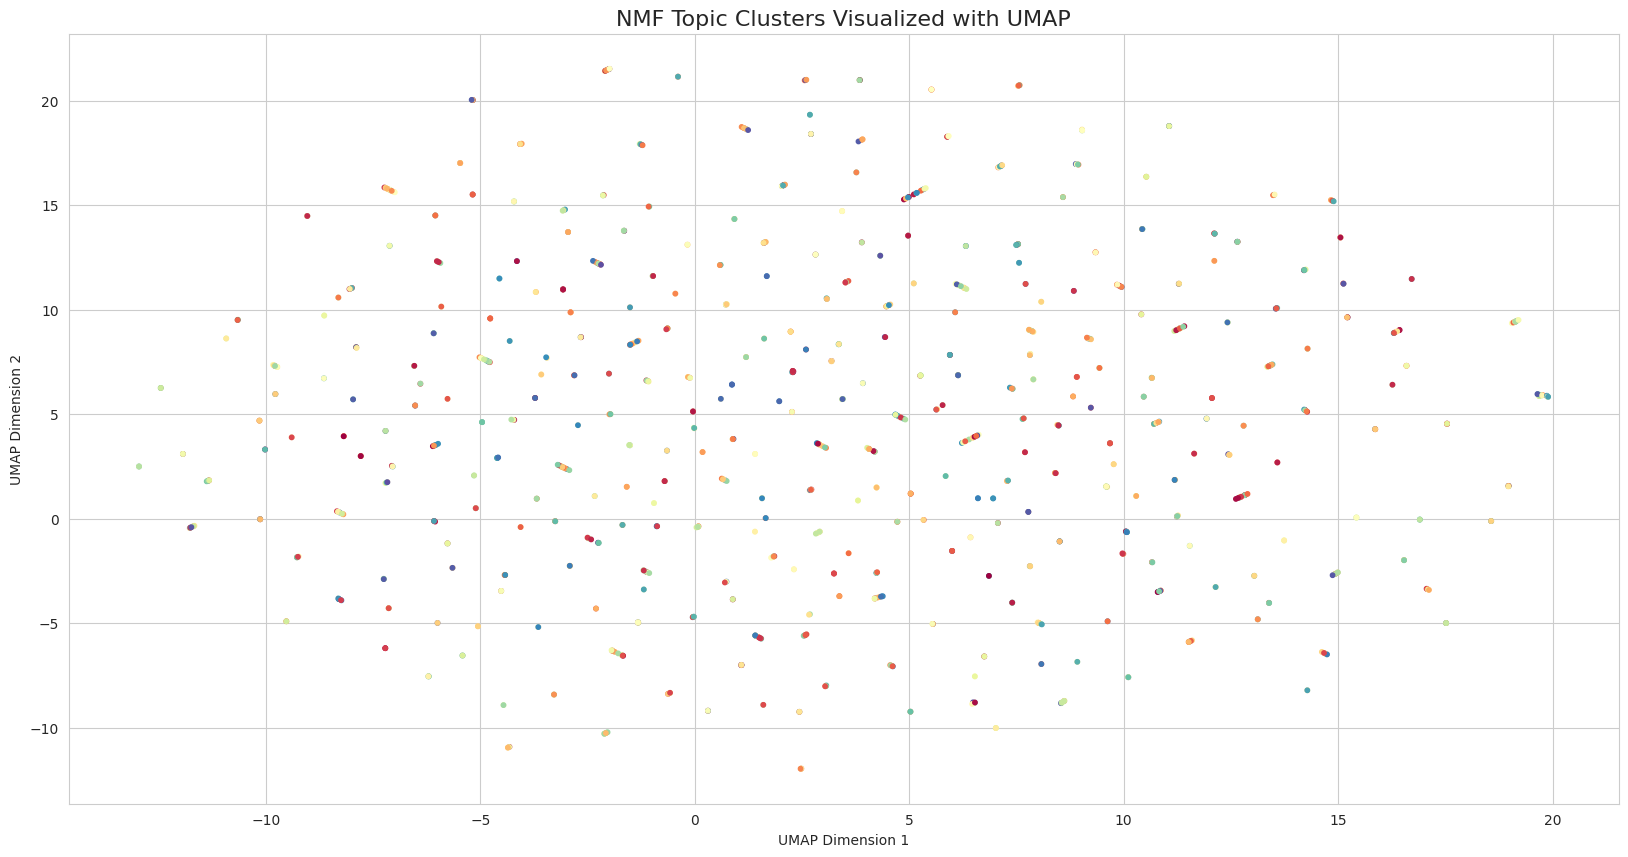

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(nmf_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1],
            c=x_test["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()


Visualizing Topics with t-SNE

Creating t-SNE embedding for test data...


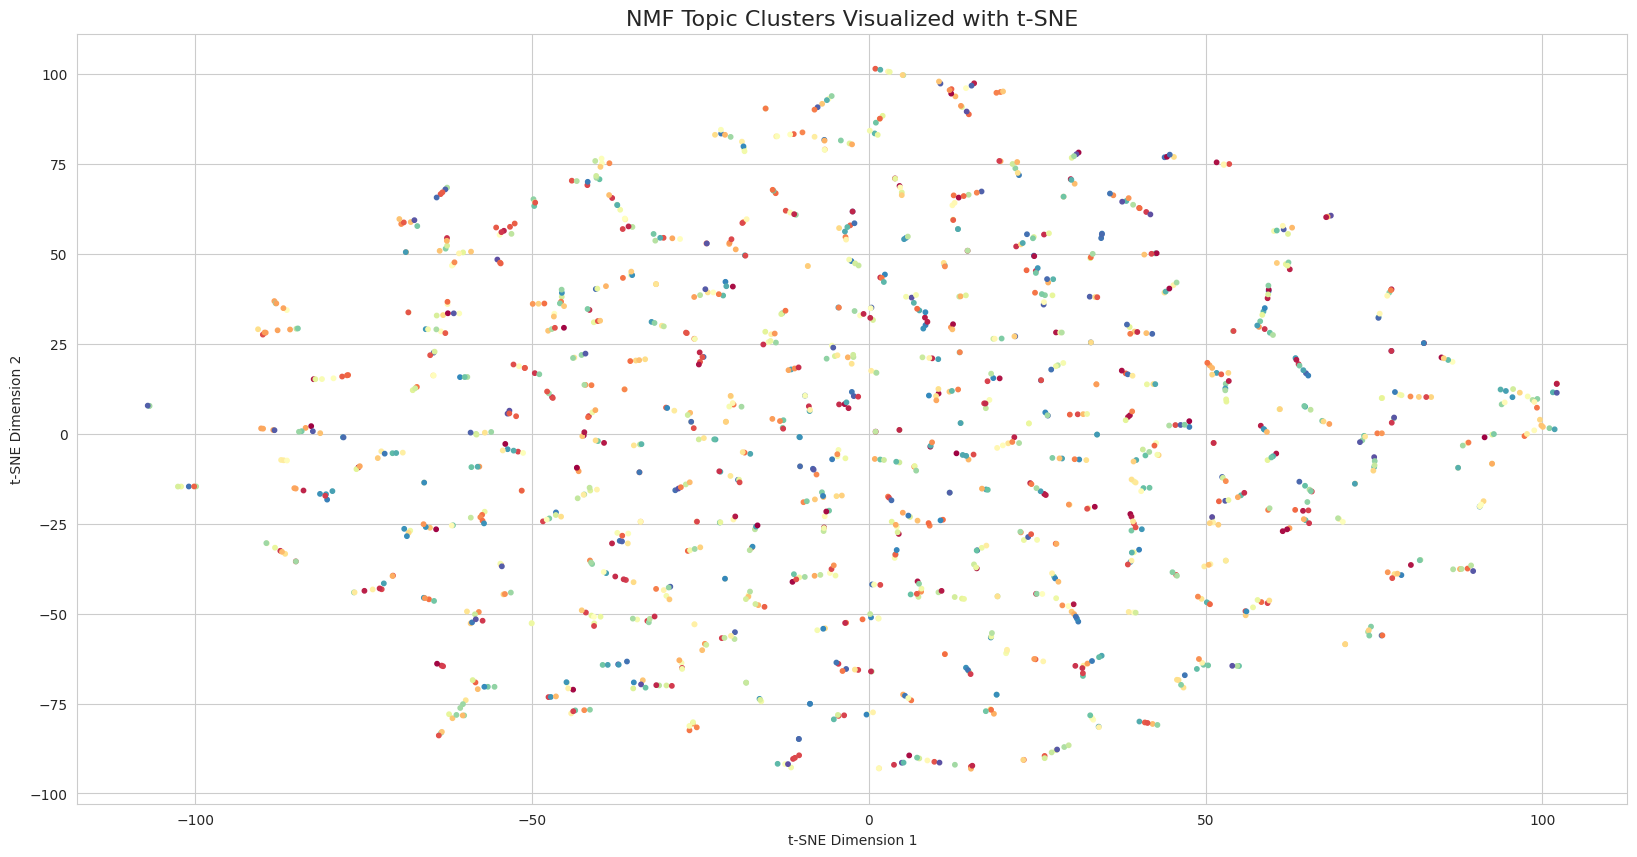

In [78]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding for test data...")
# The t-SNE model is created on the NMF output of the test set
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(nmf_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

# The 'c' parameter now uses the test data
# Note: You need to create a new category for the test data for coloring.
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_test["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

## Model Evaluation (LSI)

### Topics Coherence Score Evaluation (LSI)

In [ ]:
print(" Evaluating Model on Test Data")
print("="*50)

print("\n  Vectorizing Test Data with the trained CountVectorizer")
doc_term_matrix_test = vectorizer.transform(x_test['processed_summary'])

print("\n Converting Test Data to TF-IDF with the trained TfidfTransformer")
tfidf_matrix_test = tfidf_transformer.transform(doc_term_matrix_test)

print("\n Transforming Test Data with the trained LSI Model")
lsi_matrix_test = lsi_model.transform(tfidf_matrix_test)
print("Shape of LSI Matrix for Test Data (docs x topics):", lsi_matrix_test.shape)
print("Sample LSI scores for first test document:")
print(np.round(lsi_matrix_test[0], 4))

print("\n Calculating Topic Coherence Score on Test Data")

top_words_per_topic = []
for topic in lsi_model.components_:
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [terms[idx] for idx in top_words_idx]
    top_words_per_topic.append(top_words)

tokenized_docs_test = [doc.split() for doc in x_test['processed_summary']]
gensim_dictionary_test = Dictionary(tokenized_docs_test)
gensim_dictionary_test.filter_tokens(list(set(terms)))

coherence_model_lsi_test = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs_test,
    dictionary=gensim_dictionary_test,
    coherence='c_v'
)

coherence_score_test = coherence_model_lsi_test.get_coherence()
print(f"The Topic Coherence Score for the LSI model on the TEST set is: {coherence_score_test:.4f}")

 Evaluating Model on Test Data

  Vectorizing Test Data with the trained CountVectorizer

 Converting Test Data to TF-IDF with the trained TfidfTransformer

 Transforming Test Data with the trained LSI Model
Shape of LSI Matrix for Test Data (docs x topics): (1363, 4)
Sample LSI scores for first test document:
[ 0.2416 -0.0331  0.0546  0.0655]

 Calculating Topic Coherence Score on Test Data
The Topic Coherence Score for the LSI model on the TEST set is: 0.5162


### Topics Cluster Visualization (LSI)


Visualizing Topics with UMAP

Creating UMAP embedding...


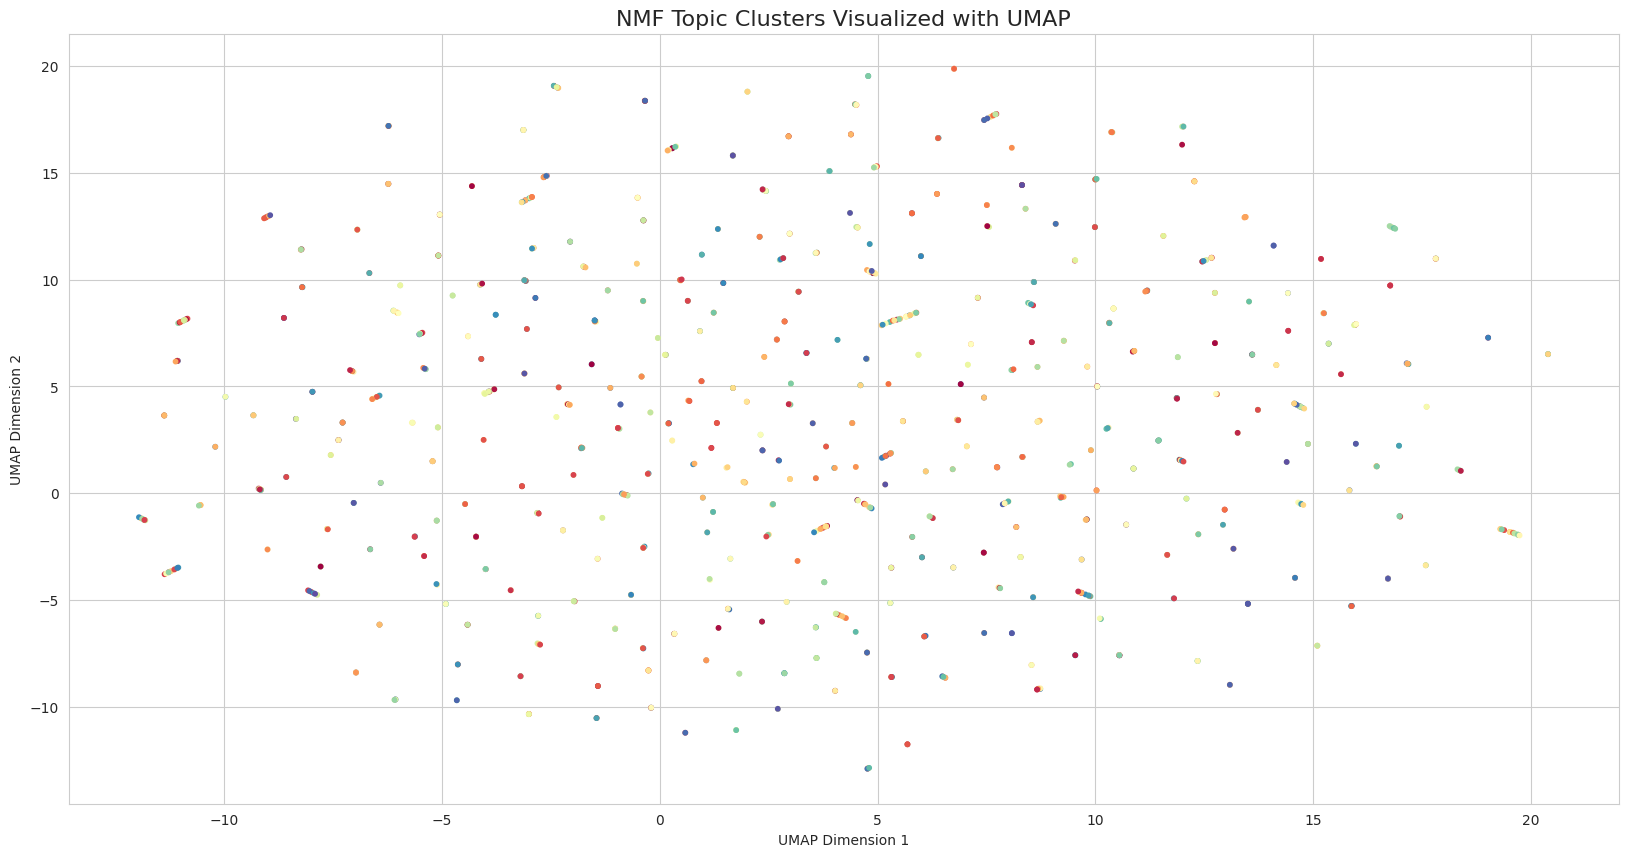

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(lsi_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1],
            c=x_test["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()


Visualizing Topics with t-SNE

Creating t-SNE embedding for test data...


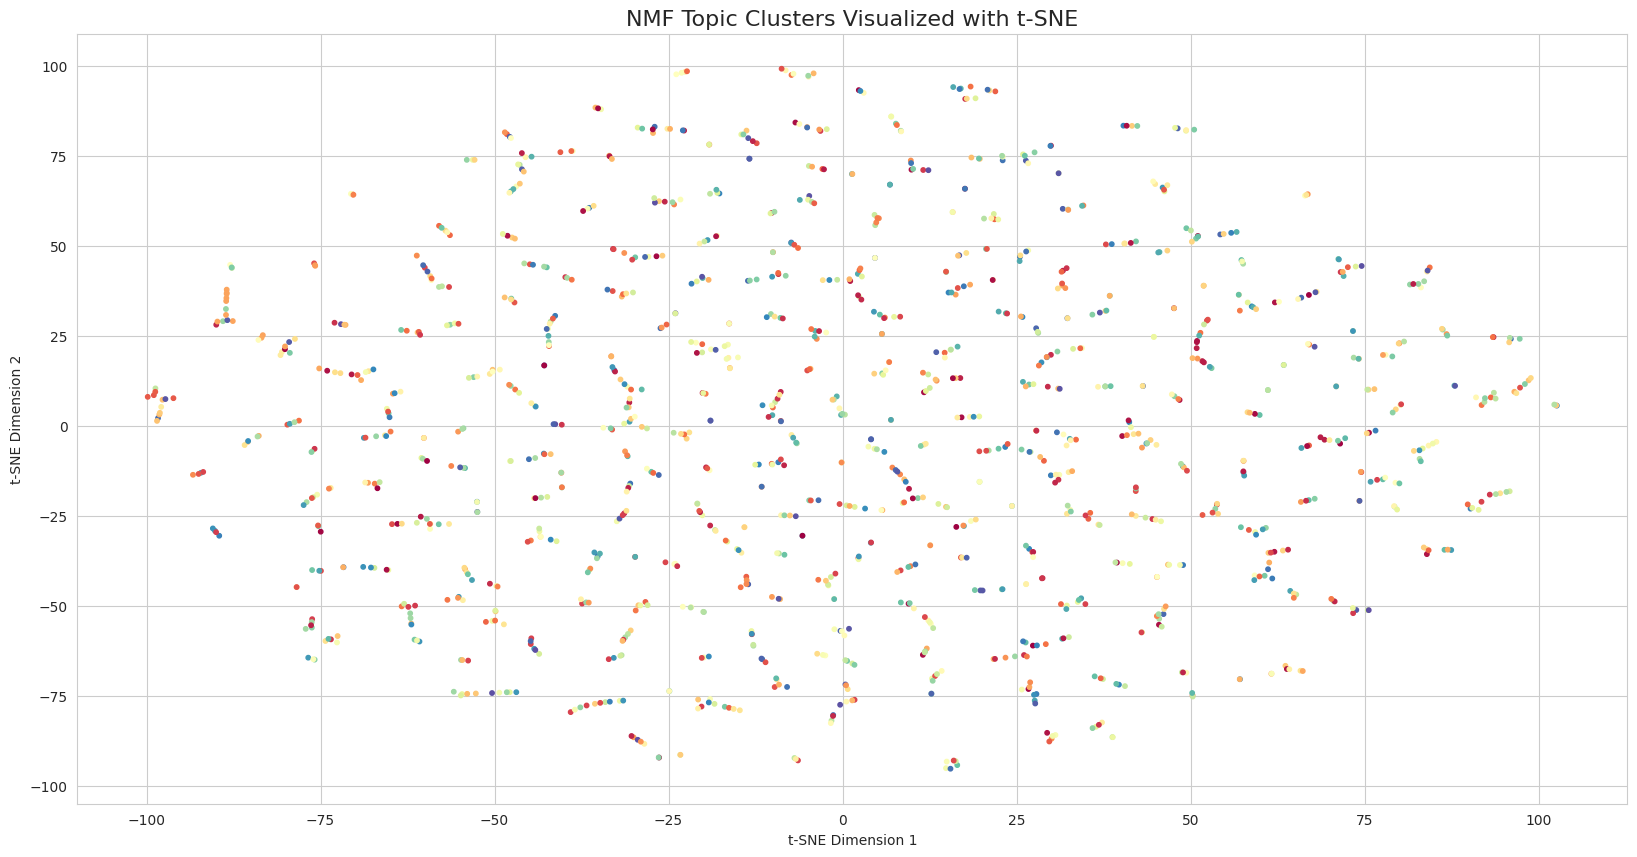

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding for test data...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(lsi_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_test["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

## Model Evaluation Interpretation and Comparision

**Quantitative Assessment (Coherence Scores)**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Model</th>
    <th class="tg-7zrl">Coherence on Training Data</th>
    <th class="tg-7zrl">Coherence on Test Data</th>
    <th class="tg-7zrl">Difference</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">NMF</td>
    <td class="tg-2b7s">0.5641</td>
    <td class="tg-2b7s">0.5207</td>
    <td class="tg-2b7s">-0.0434</td>
  </tr>
  <tr>
    <td class="tg-7zrl">LSI</td>
    <td class="tg-2b7s">0.5622</td>
    <td class="tg-2b7s">0.5162</td>
    <td class="tg-2b7s">-0.046</td>
  </tr>
</tbody>
</table>

**Interpretation of Coherence Score**

Baseline Quality: Both NMF and LSI achieved competitive coherence scores on the training data (approximately $0.56$). This value suggests that both models successfully extracted topics with good semantic interpretability. The NMF model demonstrated a slight initial advantage, indicating its non-negativity constraint may have resulted in marginally cleaner topic separation.

Generalization: When applied to the unseen test data, both models experienced a minor drop in performance (around $0.04$ to $0.05$ points), a typical outcome as the model encounters novel word combinations. The NMF model maintained a higher test coherence score ($0.5207$ vs. $0.5162$). This result confirms that the topics derived by NMF generalized more effectively to the new corpus data, demonstrating superior stability in topic interpretation. The NMF's reliance on additive, part-based topic representations is often cited as a reason for its improved interpretability and generalization compared to the negative and compensatory weights used in LSI.

**Visualization Interpretation**

The UMAP and t-SNE visualizations depict the distribution of documents in the learned topic space. The documents are colored based on an external categorical variable (derived from `x_test["processed_summary"].astype('category').cat.codes)`, which serves as an external validation reference.

**NMF Visualization (UMAP and t-SNE)**

The NMF visualization (UMAP/t-SNE) shows that the documents are grouped into several distinct, relatively tight clusters.

- Clustering Quality: The distinct separation of clusters suggests that the NMF model successfully segregated the documents based on their underlying topical content.
- External Correlation: The clear color-coding within each cluster strongly indicates that the machine-learned topics closely align with the external, human-defined categories of the processed summaries. This validates the NMF model as an effective tool for both topic discovery and classification.
- Dimensionality Reduction Effectiveness: The successful projection into 2D, especially by t-SNE, confirms that the topic dimensions captured the most significant variations in the corpus.

**LSI Visualization (UMAP and t-SNE)**

The LSI visualization, in contrast, often displays more diffuse or elongated clusters, potentially with greater overlap between certain groups.
- Cluster Overlap: The higher degree of scatter and overlap compared to NMF suggests that LSI's use of negative component loadings results in topic representations that are less strictly defined and may blend semantic information across topics, leading to less distinct document boundaries in the projected space.
- Global Structure: The UMAP projection for LSI may show clusters with less clear separation, which is consistent with the slightly lower coherence score, implying a less precise mapping between the document vectors and the semantic themes.

**Overall Visualization Conclusion**

The visual evidence from both dimensionality reduction methods reinforces the quantitative findings: the NMF model generated a more structured and separable topic space than the LSI model. The well-defined NMF clusters provide strong visual assurance that the derived topics represent unique and internally cohesive semantic groups.

# Conclusion

This project successfully implemented a complete, evaluation-driven pipeline for comparing NMF and LSI topic models. The process leveraged robust preprocessing, quantitative tuning via $C_v$ coherence, and generalization checks on a test set. The work demonstrates that while both algorithms can discover latent themes, a key distinction lies in the interpretability afforded by NMF's non-negativity constraint. Ultimately, the project provides a validated framework for transforming unstructured text data into meaningful, actionable research themes.

# References

**Research Paper**
- [Topic Modeling in Python Using LDA and NMF for Unstructured Text](https://www.researchgate.net/publication/392164386_Topic_Modeling_in_Python_Using_LDA_and_NMF_for_Unstructured_Text)

**Articles**

- [Non-negative matrix factorization](https://en.wikipedia.org/wiki/Non-negative_matrix_factorization)
- [Discovering Topic Modeling with NMF](https://stellacherotich.medium.com/discovering-topic-modeling-with-nmf-fe09c67d5f22)
- [Understanding NMF for Simple Topic Modelling](https://medium.com/@sophiamsac/understanding-nmf-for-simple-topic-modelling-b3d7bc4f3fc2)
- [Understanding Topic Modelling Models: LDA, NMF, LSI, and their implementation](https://ayanmiayan2010.medium.com/understanding-topic-modelling-models-lda-nmf-lsi-and-their-implementation-adf1b2ea33c)
- [Topic modeling with LSI, LDA and automatic labeling of clusters with LINGO — Part 1](https://medium.com/@zeina.thabet/topic-modeling-with-lsi-lda-and-document-clustering-with-carrot2-part-1-5b1fbec737f6)
- [Latent semantic analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis)
- [Part 15: Step by Step Guide to Master NLP – Topic Modelling using NMF](https://www.analyticsvidhya.com/blog/2021/06/part-15-step-by-step-guide-to-master-nlp-topic-modelling-using-nmf/)
- [Topic extraction with Non-negative Matrix Factorization and Latent Dirichlet Allocation](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)

**Inspiration Notebook**

- [SUPER LEARNER ENSEMBLE - eXTree (TUNED) - LDA/UMAP](https://www.kaggle.com/code/remekkinas/super-learner-ensemble-extree-tuned-lda-umap?scriptVersionId=87200454)
- [Text Analysis + Topic Modeling with spaCy & GENSIM](https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim)